<center>
    <h1 style="color:#FF4B4B; font-size: 2.5em;"><b>Credit Card Fraud Detection System (Universal)</b></h1>
    <h3 style="color:#A0AEC0;">Universal Validation Notebook (Local, Cloud, Streamlit)</h3>
    <h4 style="color:#718096;">Works on GitHub, cloud environments, and Streamlit deployments</h4>
    <hr style="border: 1px solid #4A5568;">
</center>

## Project Overview

This notebook is a universal testing version of the main pipeline, configured for:

- Dynamic project root detection (relative to script location)
- Automatic device selection (CUDA, MPS, or CPU)
- Configurable data sampling for faster iteration
- Streamlit-compatible output paths

Works seamlessly on local machines, GitHub, cloud services, and Streamlit deployments.


In [ ]:
# ================================================================
# ENVIRONMENT SETUP (UNIVERSAL - LOCAL, CLOUD, STREAMLIT)
# ================================================================

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')  # Clean notebook output

# Sample fraction for faster iteration (configurable via environment)
SAMPLE_FRAC = float(os.environ.get('SAMPLE_FRAC', '0.2'))  # 20% sample by default

# Universal safety switches
os.environ.setdefault('BUILD_HETERO_GRAPH', '0')
os.environ.setdefault('CUDA_DEVICE_ORDER', 'PCI_BUS_ID')
os.environ.setdefault('XGB_GPU_ID', '-1')

# Stabilize thread pools across all platforms
os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MKL_NUM_THREADS', '1')
os.environ.setdefault('VECLIB_MAXIMUM_THREADS', '1')
os.environ.setdefault('NUMEXPR_NUM_THREADS', '1')
os.environ.setdefault('XGB_N_JOBS', '1')


def locate_project_root() -> Path:
    """
    Locate project root containing src/config.py.
    Works across multiple environments: local, cloud, Streamlit, GitHub.
    """
    # 1) Respect explicit env var first
    env_root = os.environ.get('PROJECT_ROOT')
    if env_root:
        p = Path(env_root).expanduser().resolve()
        if (p / 'src' / 'config.py').exists():
            return p

    # 2) Start from notebook/script location
    cwd = Path.cwd().resolve()
    
    # Check current directory and parents
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'src' / 'config.py').exists():
            return candidate
    
    # 3) Check for common paths relative to notebook
    notebook_dir = Path(__file__).resolve().parent if '__file__' in dir() else cwd
    for relative_path in ['..', '../..', '../../..']:
        candidate = (notebook_dir / relative_path).resolve()
        if (candidate / 'src' / 'config.py').exists():
            return candidate

    raise RuntimeError(
        'Could not locate project root containing src/config.py. '
        'Set PROJECT_ROOT environment variable or ensure notebook is in correct location.'
    )


project_root = locate_project_root()
os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import joblib
from sklearn.metrics import classification_report

# Project modules
from src.config import *
from src.utils import set_plot_style, format_number, format_pct, Timer, get_logger

logger = get_logger('NotebookUniversal')
set_plot_style()

print(f'Python:  {sys.version}')
print(f'NumPy:   {np.__version__}')
print(f'Pandas:  {pd.__version__}')
print(f'PyTorch: {torch.__version__}')

# Auto-detect device
if torch.cuda.is_available():
    device_name = f"CUDA ({torch.cuda.get_device_name(0)})"
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device_name = 'MPS'
else:
    device_name = 'CPU'

print(f'Device:  {device_name}')
print(f'\nProject Root: {os.getcwd()}')
print(f'Data Dir:     {DATA_DIR}')
print(f'Sample Fraction: {SAMPLE_FRAC}')
print(f'Build Hetero Graph: {os.environ.get("BUILD_HETERO_GRAPH")}')
print(f'XGBoost n_jobs: {os.environ.get("XGB_N_JOBS")}')
print(f'OMP threads: {os.environ.get("OMP_NUM_THREADS")}')


Python:  3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 17.0.0 (clang-1700.6.3.2)]
NumPy:   2.4.4
Pandas:  3.0.2
PyTorch: 2.11.0
Device:  MPS

Project Root: /Users/aaronr/Desktop/PROJECT3
Data Dir:     /Users/aaronr/Desktop/PROJECT3/ieee-fraud-detection
Local Sample Fraction: 0.2
Build Hetero Graph: 0
XGBoost n_jobs: 1
OMP threads: 1


In [ ]:
# HGNN training curves
if 'nn_history' in globals() and nn_history:
    set_plot_style()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(nn_history['train_losses'], color=COLORS['fraud'], linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].set_title('Training Loss (Focal Loss)', fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Validation AUC curve
    axes[1].plot(nn_history['val_aucs'], color=COLORS['legit'], linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].set_title('Validation ROC-AUC', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    fig.suptitle('DenseHGNN-ATT-TD Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, '06_dense_hgnn_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping training curves: nn_history not available in current session.')

Skipping training curves: nn_history not available in current session.


---
## <b><font color='#FF4B4B'>Stage 1: Problem Definition & Literature Review</font></b>

### 1.1 Problem Statement

Credit card fraud is a significant concern in the financial industry, with global losses exceeding **$30 billion annually**. The challenge is to build an automated system that can detect fraudulent transactions in real-time with high accuracy while minimizing false negatives (missed frauds).

**Task**: Binary classification — predict whether a transaction is fraudulent (`isFraud=1`) or legitimate (`isFraud=0`).

### 1.2 Key Challenges

1. **Severe Class Imbalance**: Only ~3.5% of transactions are fraudulent (ratio ~1:28)
2. **High Dimensionality**: 434 features (transaction + identity) with many anonymized
3. **Cost Asymmetry**: Missing a fraud (FN=$500) is far more costly than a false alarm (FP=$10)
4. **Feature Interpretability**: V1-V339 are anonymized; domain knowledge is limited

### 1.3 Literature & Methodology

| Technique | Reference | Purpose |
|-----------|-----------|----------|
| SMOTE | Chawla et al. (2002) | Synthetic oversampling for class imbalance |
| XGBoost | Chen & Guestrin (2016) | Gradient boosted trees; state-of-the-art for tabular data |
| Focal Loss | Lin et al. (2017) | Down-weights easy examples; focuses on hard negatives |
| SHAP | Lundberg & Lee (2017) | Unified feature attribution for model explainability |
| Cost-Sensitive Learning | Elkan (2001) | Asymmetric misclassification costs |

### 1.4 Success Metrics

Given the severe class imbalance, **accuracy is NOT a suitable metric** (a model predicting all legitimate would achieve 96.5% accuracy). Instead, we focus on:

- **AUPRC** (Area Under Precision-Recall Curve) — primary metric
- **Recall** (Sensitivity) — minimize false negatives
- **F1-Score** — harmonic mean of precision and recall
- **Total Cost** — weighted sum using business cost assumptions

---
## <b><font color='#FF4B4B'>Stage 2: Data Collection & Understanding</font></b>

The **IEEE-CIS Fraud Detection dataset** was released as part of a Kaggle competition hosted by the IEEE Computational Intelligence Society and Vesta Corporation. It contains real-world e-commerce transaction data.

**Two tables:**
- `train_transaction.csv`: 590,540 rows × 394 columns (transaction features)
- `train_identity.csv`: 144,233 rows × 41 columns (device/network identity features)
- Joined on `TransactionID` (left join — ~24% of transactions have identity data)

In [ ]:
# ================================================================
# STAGE 2: DATA LOADING
# ================================================================

from src.data_loader import load_raw_data, get_dataset_summary

# Load data with configurable sampling for flexible deployment
sample_frac = None if SAMPLE_FRAC >= 1.0 else SAMPLE_FRAC
df = load_raw_data(sample_frac=sample_frac)

# Generate comprehensive summary
summary = get_dataset_summary(df)


2026-04-10 16:36:17 | DataLoader           | INFO    | ⏳ Starting: Loading transaction data
2026-04-10 16:36:21 | DataLoader           | INFO    |   Transactions: 590,540 rows × 394 cols
2026-04-10 16:36:21 | DataLoader           | INFO    | ✅ Finished: Loading transaction data (4.1s)
2026-04-10 16:36:21 | DataLoader           | INFO    | ⏳ Starting: Loading identity data
2026-04-10 16:36:21 | DataLoader           | INFO    |   Identity:     144,233 rows × 41 cols
2026-04-10 16:36:21 | DataLoader           | INFO    | ✅ Finished: Loading identity data (0.2s)
2026-04-10 16:36:21 | DataLoader           | INFO    | ⏳ Starting: Merging datasets on TransactionID
2026-04-10 16:36:21 | DataLoader           | INFO    |   Merged:       590,540 rows × 434 cols
2026-04-10 16:36:21 | DataLoader           | INFO    | ✅ Finished: Merging datasets on TransactionID (0.1s)
2026-04-10 16:36:21 | DataLoader           | INFO    | ⏳ Starting: Optimizing memory usage
2026-04-10 16:36:24 | DataLoader        

  Memory: 2567.1 MB → 1656.4 MB (35.5% reduction)


2026-04-10 16:36:25 | DataLoader           | INFO    |   Sampled: 590,540 → 118,108 rows (20.00%)
2026-04-10 16:36:25 | DataLoader           | INFO    | ============================================================
2026-04-10 16:36:25 | DataLoader           | INFO    |          DATASET SUMMARY
2026-04-10 16:36:25 | DataLoader           | INFO    | ============================================================
2026-04-10 16:36:25 | DataLoader           | INFO    |   Total samples:     118,108
2026-04-10 16:36:25 | DataLoader           | INFO    |   Total features:    434
2026-04-10 16:36:25 | DataLoader           | INFO    |   Fraud (1):         4,242 (3.59%)
2026-04-10 16:36:25 | DataLoader           | INFO    |   Legitimate (0):    113,866 (96.41%)
2026-04-10 16:36:25 | DataLoader           | INFO    |   Imbalance ratio:   1:26.8
2026-04-10 16:36:25 | DataLoader           | INFO    |   Numeric features:  403
2026-04-10 16:36:25 | DataLoader           | INFO    |   Categorical:       31
2

In [6]:
# Dataset shape and first few rows
print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Groups:')
print(f'  Transaction features (card, addr, dist, email): {394} columns')
print(f'  Identity features (device, browser, OS):        {41} columns')
print(f'  Total after merge:                              {df.shape[1]} columns')

# Display sample
df.head(3)

Dataset Shape: (118108, 434)

Column Groups:
  Transaction features (card, addr, dist, email): 394 columns
  Identity features (device, browser, OS):        41 columns
  Total after merge:                              434 columns


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,3457624,0,12153579,724.000000,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3552820,0,15005886,108.500000,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3271083,0,6970178,47.950001,W,9400,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Class distribution
print('\n📊 CLASS DISTRIBUTION')
print('=' * 40)
class_counts = df[TARGET_COL].value_counts()
print(f'Legitimate (0): {format_number(class_counts[0])} ({format_pct(class_counts[0]/len(df))})')
print(f'Fraudulent (1): {format_number(class_counts[1])} ({format_pct(class_counts[1]/len(df))})')
print(f'Imbalance Ratio: 1:{class_counts[0]/class_counts[1]:.1f}')
print(f'\n⚠️  This confirms SEVERE class imbalance — standard accuracy is misleading!')


📊 CLASS DISTRIBUTION
Legitimate (0): 113,866 (96.41%)
Fraudulent (1): 4,242 (3.59%)
Imbalance Ratio: 1:26.8

⚠️  This confirms SEVERE class imbalance — standard accuracy is misleading!


In [8]:
# Data types overview
print('\n📋 DATA TYPES')
print('=' * 40)
print(df.dtypes.value_counts())
print(f'\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')

# Missing values overview
missing = df.isnull().mean().sort_values(ascending=False)
print(f'\n📋 MISSING VALUES')
print(f'  Columns with 0% missing:   {(missing == 0).sum()}')
print(f'  Columns with <50% missing: {((missing > 0) & (missing < 0.5)).sum()}')
print(f'  Columns with ≥50% missing: {(missing >= 0.5).sum()}')


📋 DATA TYPES
float32    399
str         31
int32        2
int8         1
int16        1
Name: count, dtype: int64

Memory Usage: 331.3 MB

📋 MISSING VALUES
  Columns with 0% missing:   20
  Columns with <50% missing: 200
  Columns with ≥50% missing: 214


---
## <b><font color='#FF4B4B'>Stage 3: Data Preprocessing & Cleaning</font></b>

Our preprocessing pipeline handles:
1. **Missing values**: Drop columns with >50% missing; median impute numeric; 'Unknown' for categorical
2. **Outlier capping**: TransactionAmt capped at 99th percentile
3. **Categorical encoding**: LabelEncoder for all categorical features
4. **Stratified split**: 70% train / 15% validation / 15% test (preserves fraud rate)
5. **Feature scaling**: StandardScaler fitted on training data only (prevents data leakage)

In [3]:
# ════════════════════════════════════════════════════════════════
# STAGE 3: PREPROCESSING
# ════════════════════════════════════════════════════════════════

from src.preprocessing import run_preprocessing_pipeline

prep_result = run_preprocessing_pipeline(df)

X_train = prep_result['X_train']
X_val   = prep_result['X_val']
X_test  = prep_result['X_test']
y_train = prep_result['y_train']
y_val   = prep_result['y_val']
y_test  = prep_result['y_test']
feature_names = prep_result['feature_names']

print(f'\n✅ Preprocessing Complete!')
print(f'   Train: {X_train.shape} | Fraud: {y_train.sum()} ({y_train.mean():.2%})')
print(f'   Val:   {X_val.shape}  | Fraud: {y_val.sum()} ({y_val.mean():.2%})')
print(f'   Test:  {X_test.shape}  | Fraud: {y_test.sum()} ({y_test.mean():.2%})')
print(f'   Features: {len(feature_names)}')

2026-04-10 15:10:01 | Preprocessing        | INFO    | ============================================================
2026-04-10 15:10:01 | Preprocessing        | INFO    |      PREPROCESSING PIPELINE
2026-04-10 15:10:01 | Preprocessing        | INFO    | ============================================================
2026-04-10 15:10:01 | Preprocessing        | INFO    | ⏳ Starting: Handling missing values
2026-04-10 15:10:01 | Preprocessing        | INFO    |   Dropped 214 columns with >50% missing
2026-04-10 15:10:01 | Preprocessing        | INFO    |   Features: 434 → 220 (removed 214)
2026-04-10 15:10:01 | Preprocessing        | INFO    |   Remaining nulls: 0
2026-04-10 15:10:01 | Preprocessing        | INFO    | ✅ Finished: Handling missing values (0.2s)
2026-04-10 15:10:01 | Preprocessing        | INFO    | ⏳ Starting: Capping outliers
2026-04-10 15:10:01 | Preprocessing        | INFO    |   Capped 1,114 outliers in TransactionAmt at 1104.00
2026-04-10 15:10:01 | Preprocessing       


✅ Preprocessing Complete!
   Train: (82674, 217) | Fraud: 2970 (3.59%)
   Val:   (17717, 217)  | Fraud: 636 (3.59%)
   Test:  (17717, 217)  | Fraud: 636 (3.59%)
   Features: 217


---
## <b><font color='#FF4B4B'>Stage 4: Exploratory Data Analysis (EDA)</font></b>

We generate 10 publication-quality visualizations to understand data patterns, class separability, and feature relationships before model training.

In [ ]:
# ================================================================
# STAGE 4: EXPLORATORY DATA ANALYSIS
# ================================================================

# Reload raw data for EDA (before preprocessing transformations)
from src.data_loader import load_raw_data
# Use the same configurable sampling strategy for consistent behavior
df_eda = load_raw_data(sample_frac=sample_frac)

from src.eda import run_eda_pipeline
eda_dir = run_eda_pipeline(df_eda)

print(f'\nAll EDA plots saved to: {eda_dir}')


2026-04-10 15:02:33 | DataLoader           | INFO    | ⏳ Starting: Loading transaction data
2026-04-10 15:02:37 | DataLoader           | INFO    |   Transactions: 590,540 rows × 394 cols
2026-04-10 15:02:37 | DataLoader           | INFO    | ✅ Finished: Loading transaction data (3.9s)
2026-04-10 15:02:37 | DataLoader           | INFO    | ⏳ Starting: Loading identity data
2026-04-10 15:02:37 | DataLoader           | INFO    |   Identity:     144,233 rows × 41 cols
2026-04-10 15:02:37 | DataLoader           | INFO    | ✅ Finished: Loading identity data (0.2s)
2026-04-10 15:02:37 | DataLoader           | INFO    | ⏳ Starting: Merging datasets on TransactionID
2026-04-10 15:02:37 | DataLoader           | INFO    |   Merged:       590,540 rows × 434 cols
2026-04-10 15:02:37 | DataLoader           | INFO    | ✅ Finished: Merging datasets on TransactionID (0.1s)
2026-04-10 15:02:37 | DataLoader           | INFO    | ⏳ Starting: Optimizing memory usage
2026-04-10 15:02:40 | DataLoader        

  Memory: 2567.1 MB → 1656.4 MB (35.5% reduction)


2026-04-10 15:02:40 | DataLoader           | INFO    |   Sampled: 590,540 → 118,108 rows (20.00%)
2026-04-10 15:02:40 | EDA                  | INFO    | ============================================================
2026-04-10 15:02:40 | EDA                  | INFO    |      EXPLORATORY DATA ANALYSIS
2026-04-10 15:02:40 | EDA                  | INFO    | ============================================================
2026-04-10 15:02:40 | EDA                  | INFO    |   ✅ Class distribution plot saved
2026-04-10 15:02:41 | EDA                  | INFO    |   ✅ Transaction amount plot saved
2026-04-10 15:02:54 | EDA                  | INFO    |   ✅ Correlation heatmap saved
2026-04-10 15:02:55 | EDA                  | INFO    |   ✅ Missing values plot saved
2026-04-10 15:02:55 | EDA                  | INFO    |   ✅ Time pattern plot saved
2026-04-10 15:02:55 | EDA                  | INFO    |   ✅ Product analysis plot saved
2026-04-10 15:02:55 | EDA                  | INFO    |   ✅ Card an


All EDA plots saved to: /Users/aaronr/Desktop/PROJECT3/outputs/eda



════════════════════════════════════════════════════════════
  Class Distribution
════════════════════════════════════════════════════════════


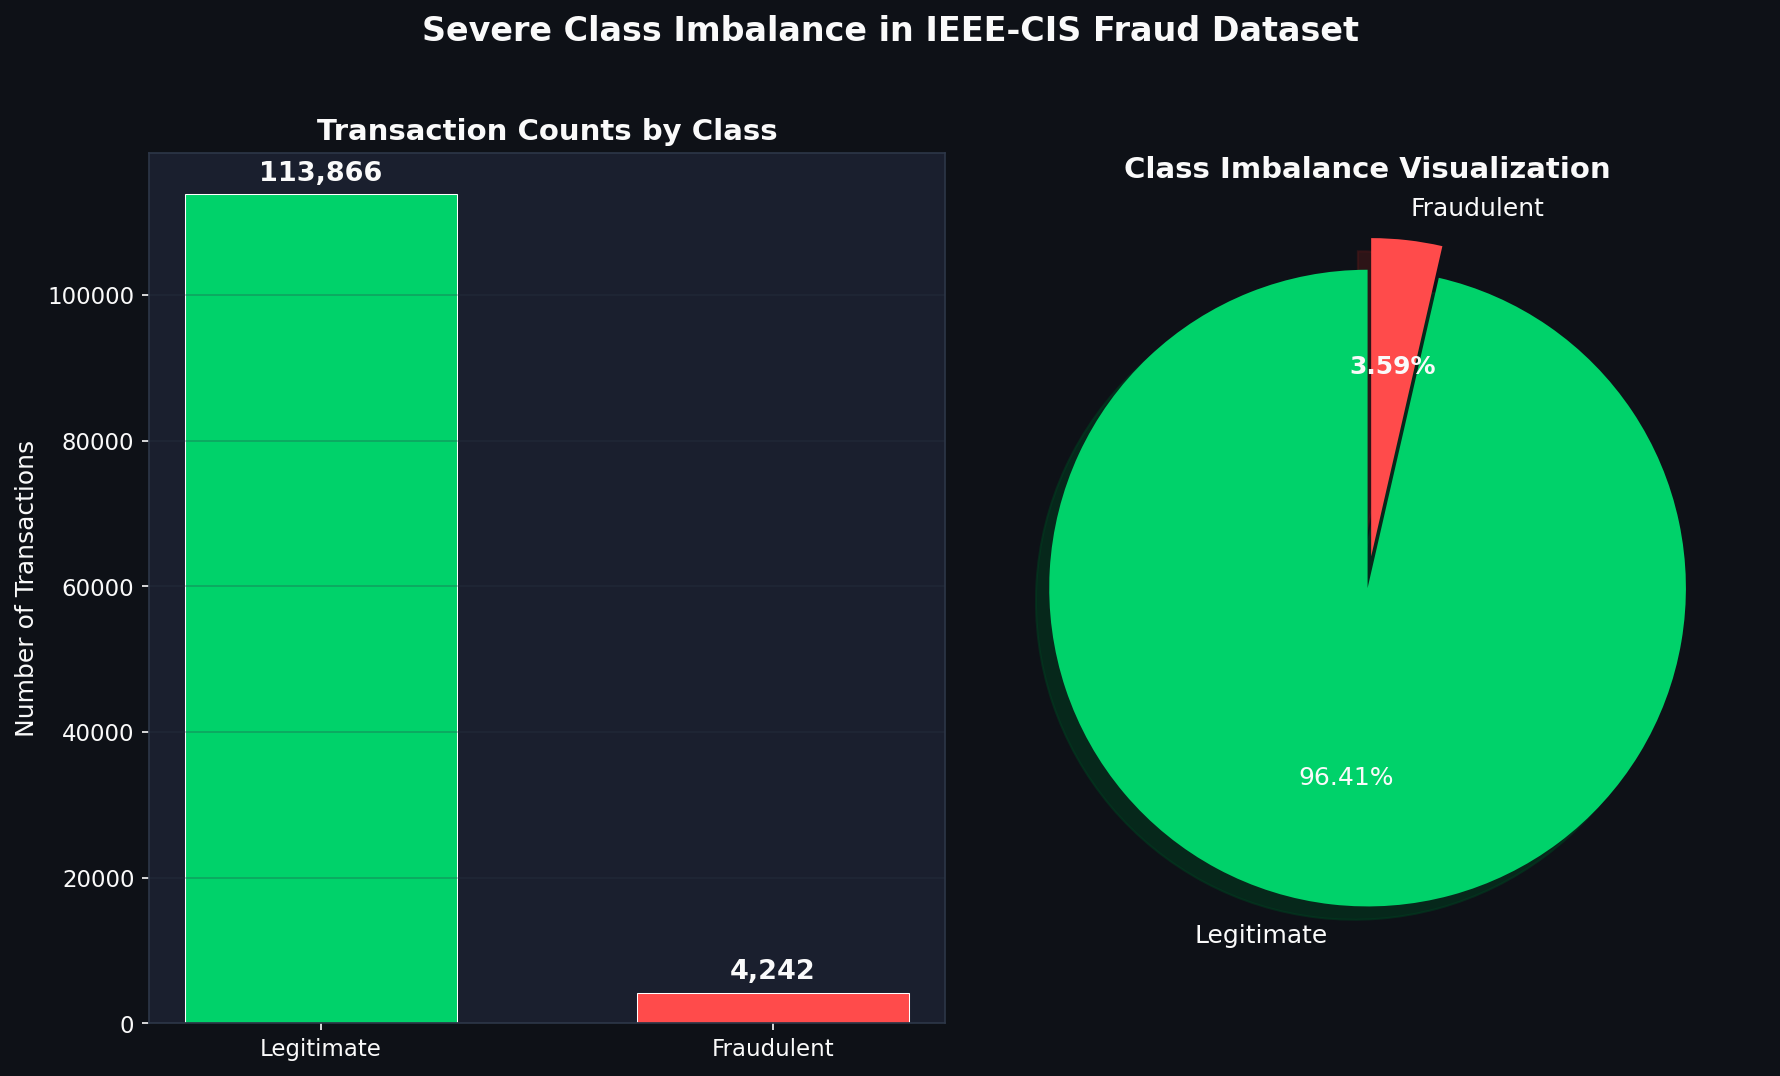


════════════════════════════════════════════════════════════
  Transaction Amount Distribution
════════════════════════════════════════════════════════════


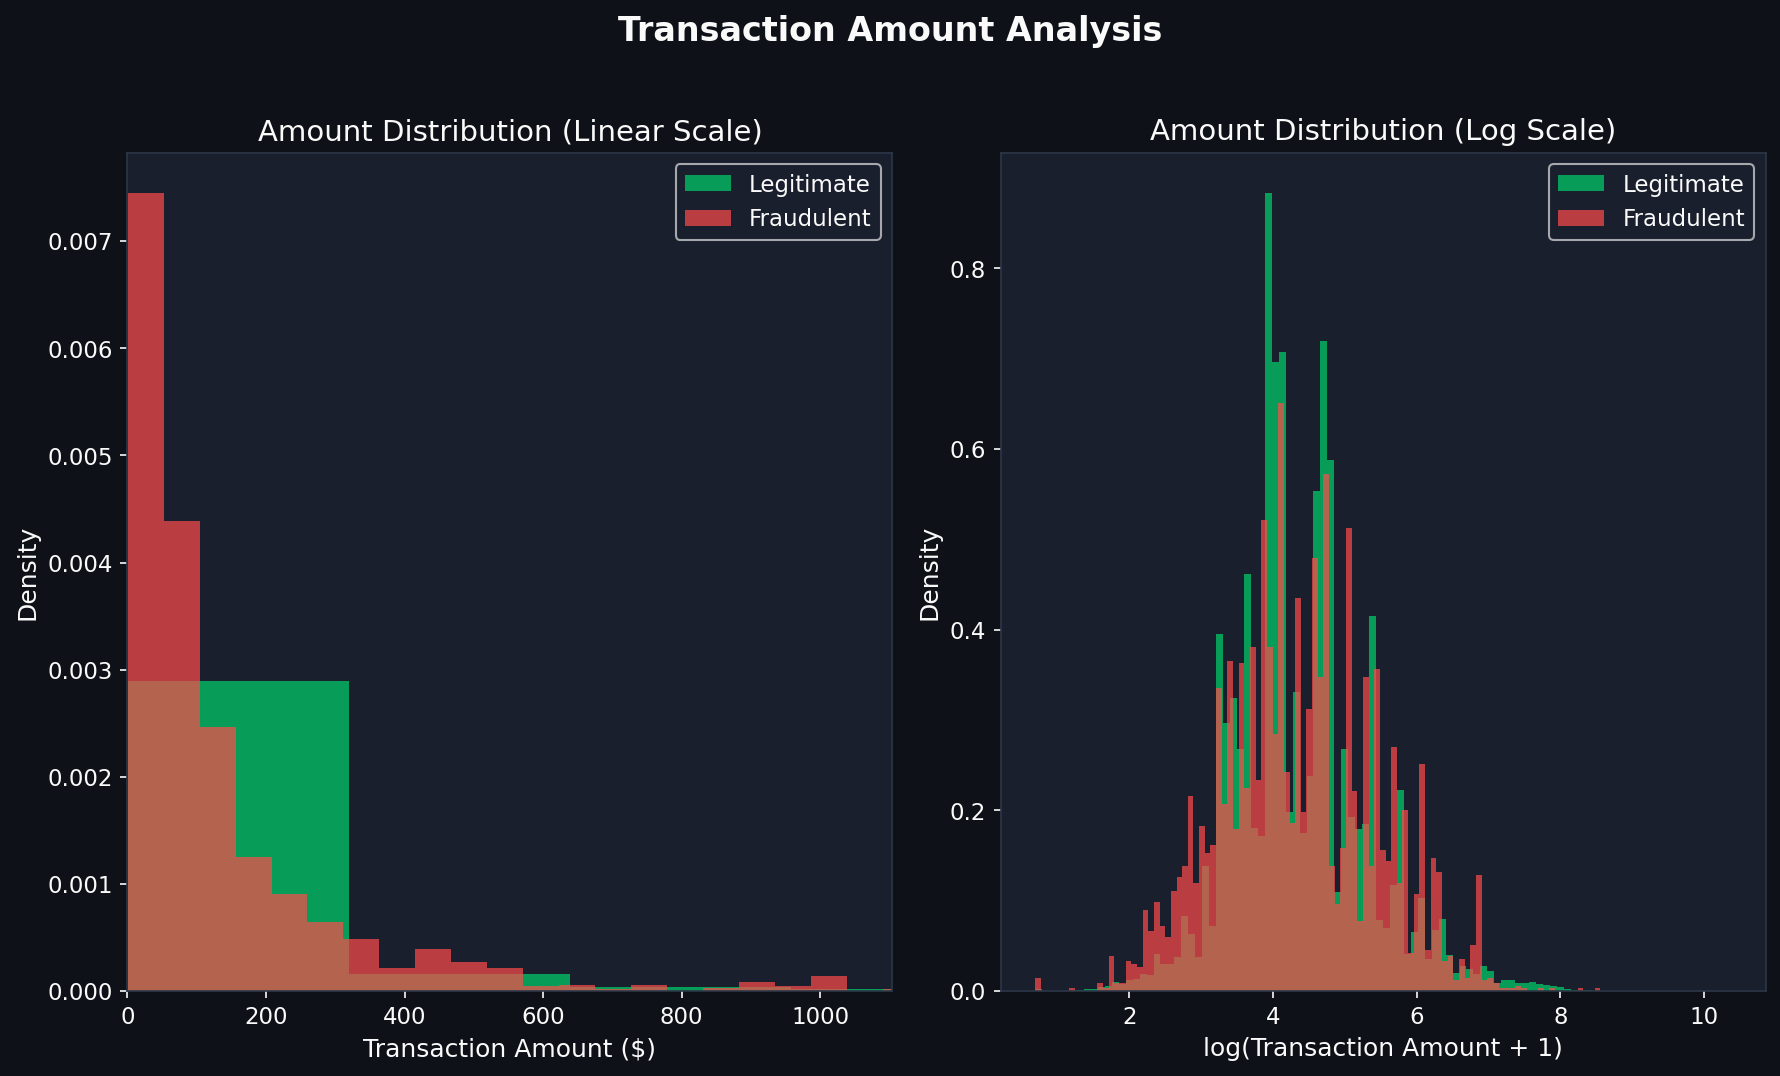


════════════════════════════════════════════════════════════
  Correlation Heatmap
════════════════════════════════════════════════════════════


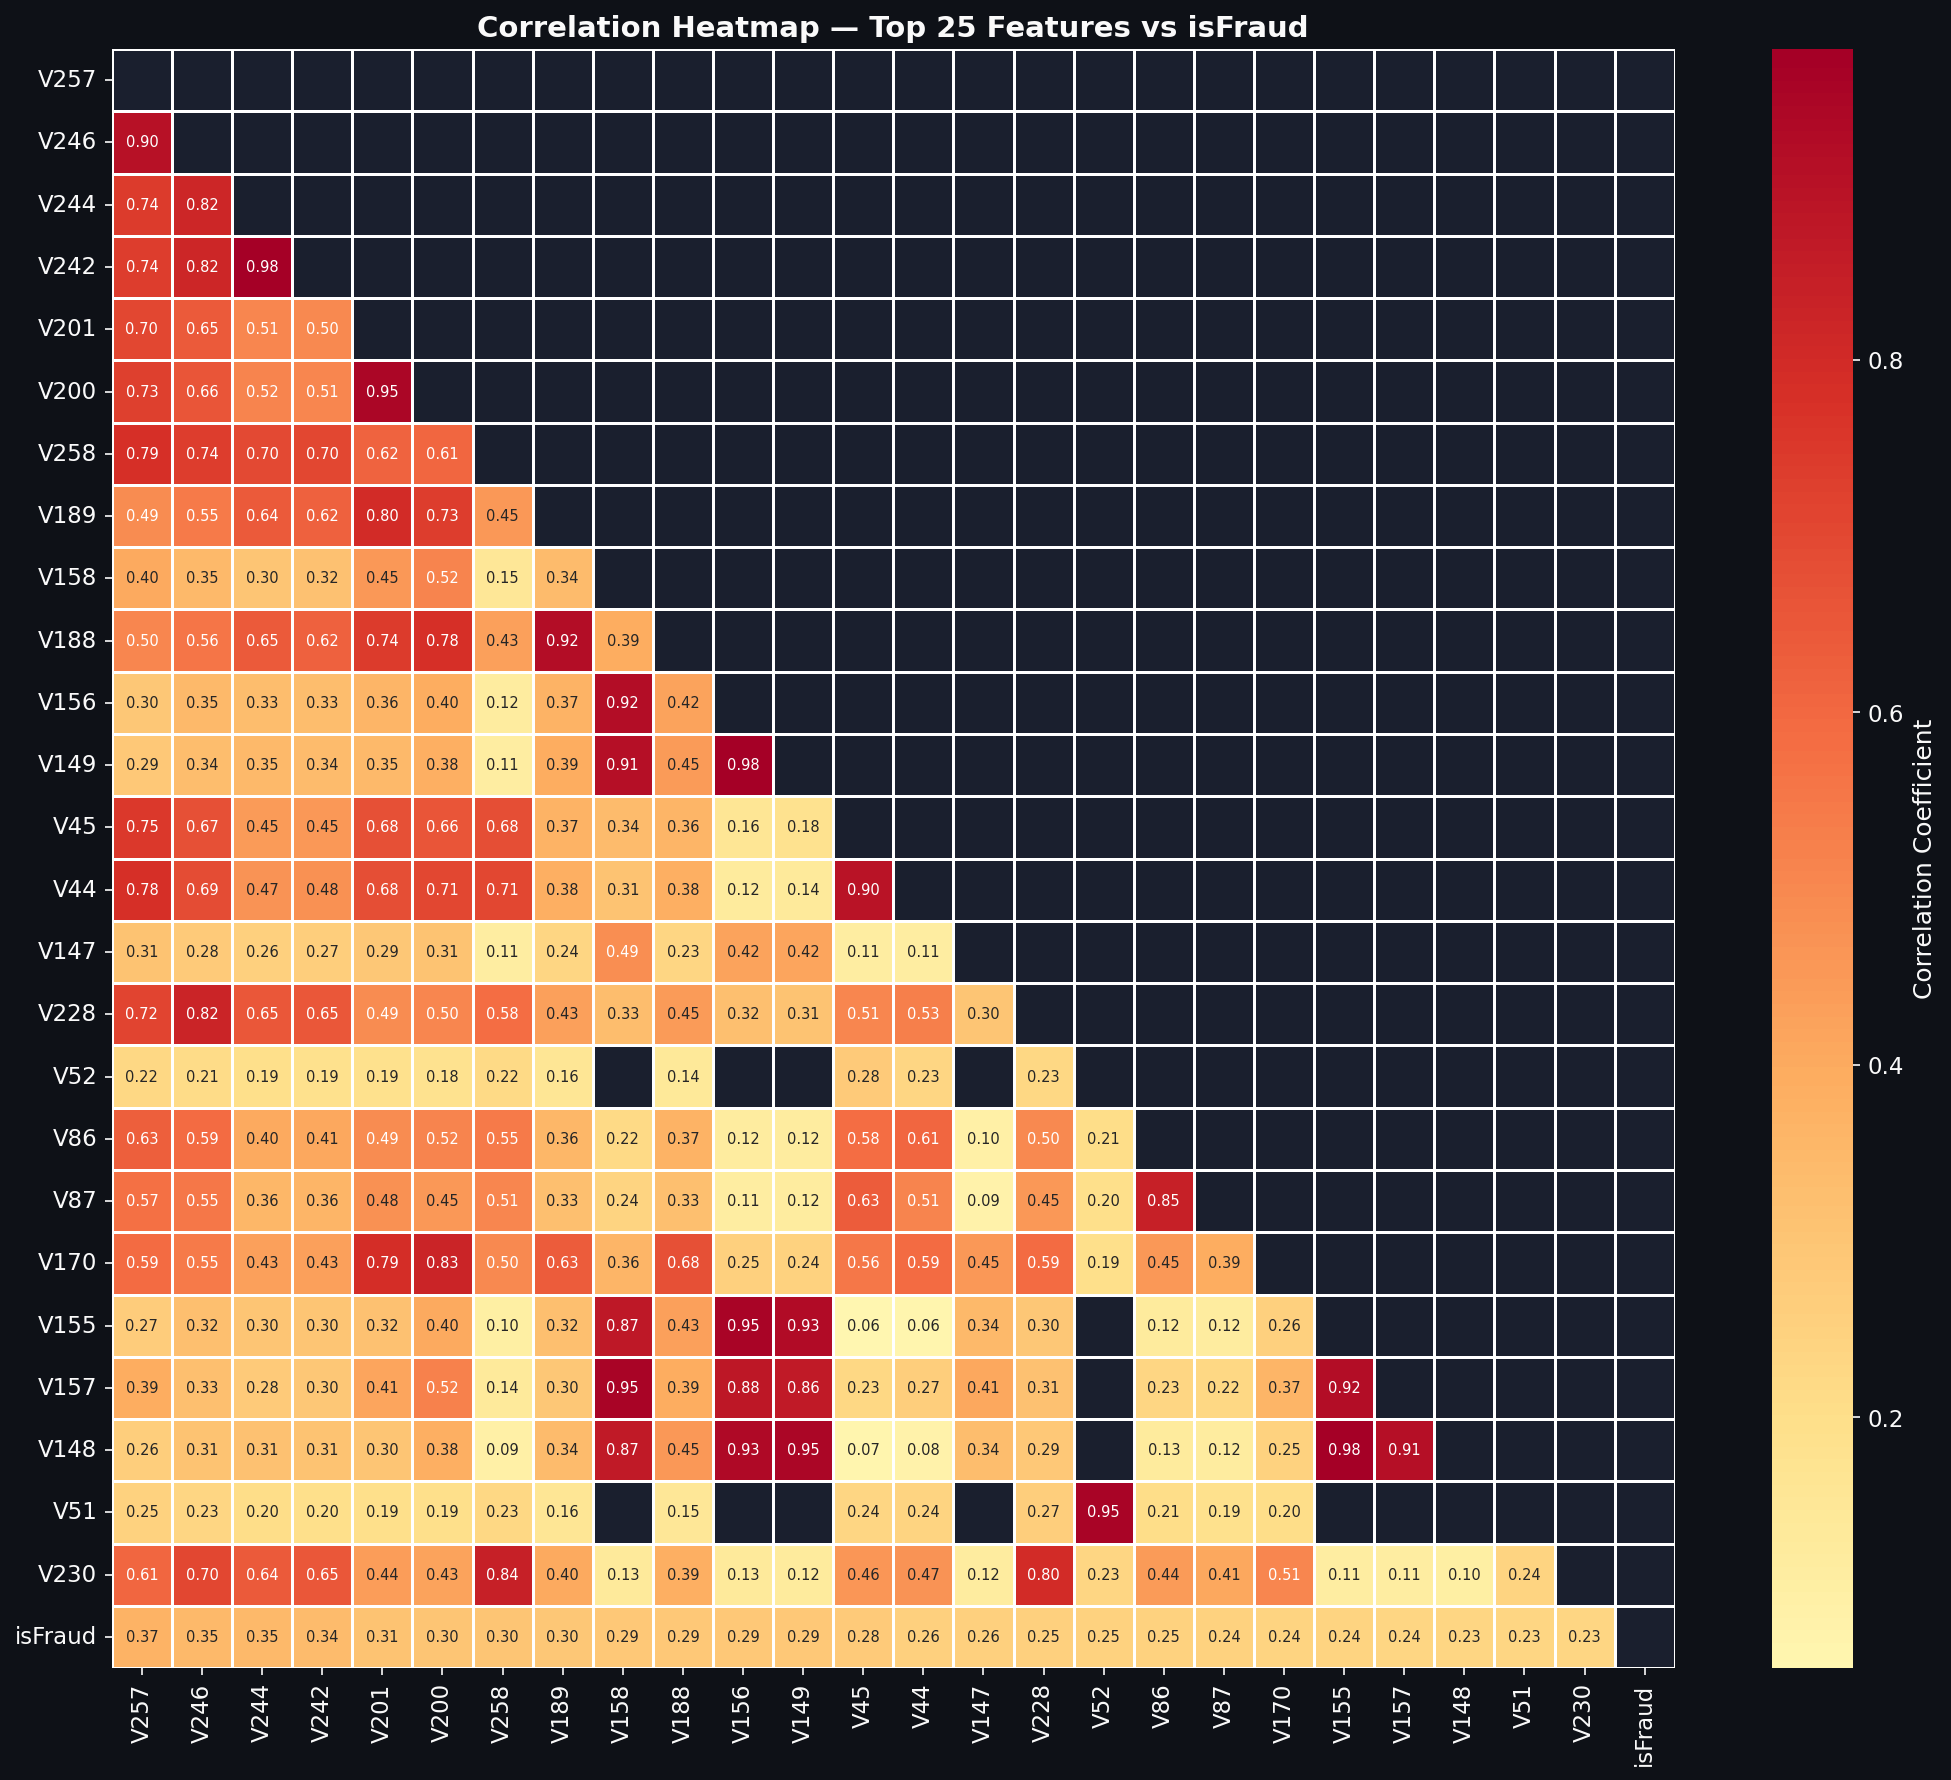


════════════════════════════════════════════════════════════
  Missing Values
════════════════════════════════════════════════════════════


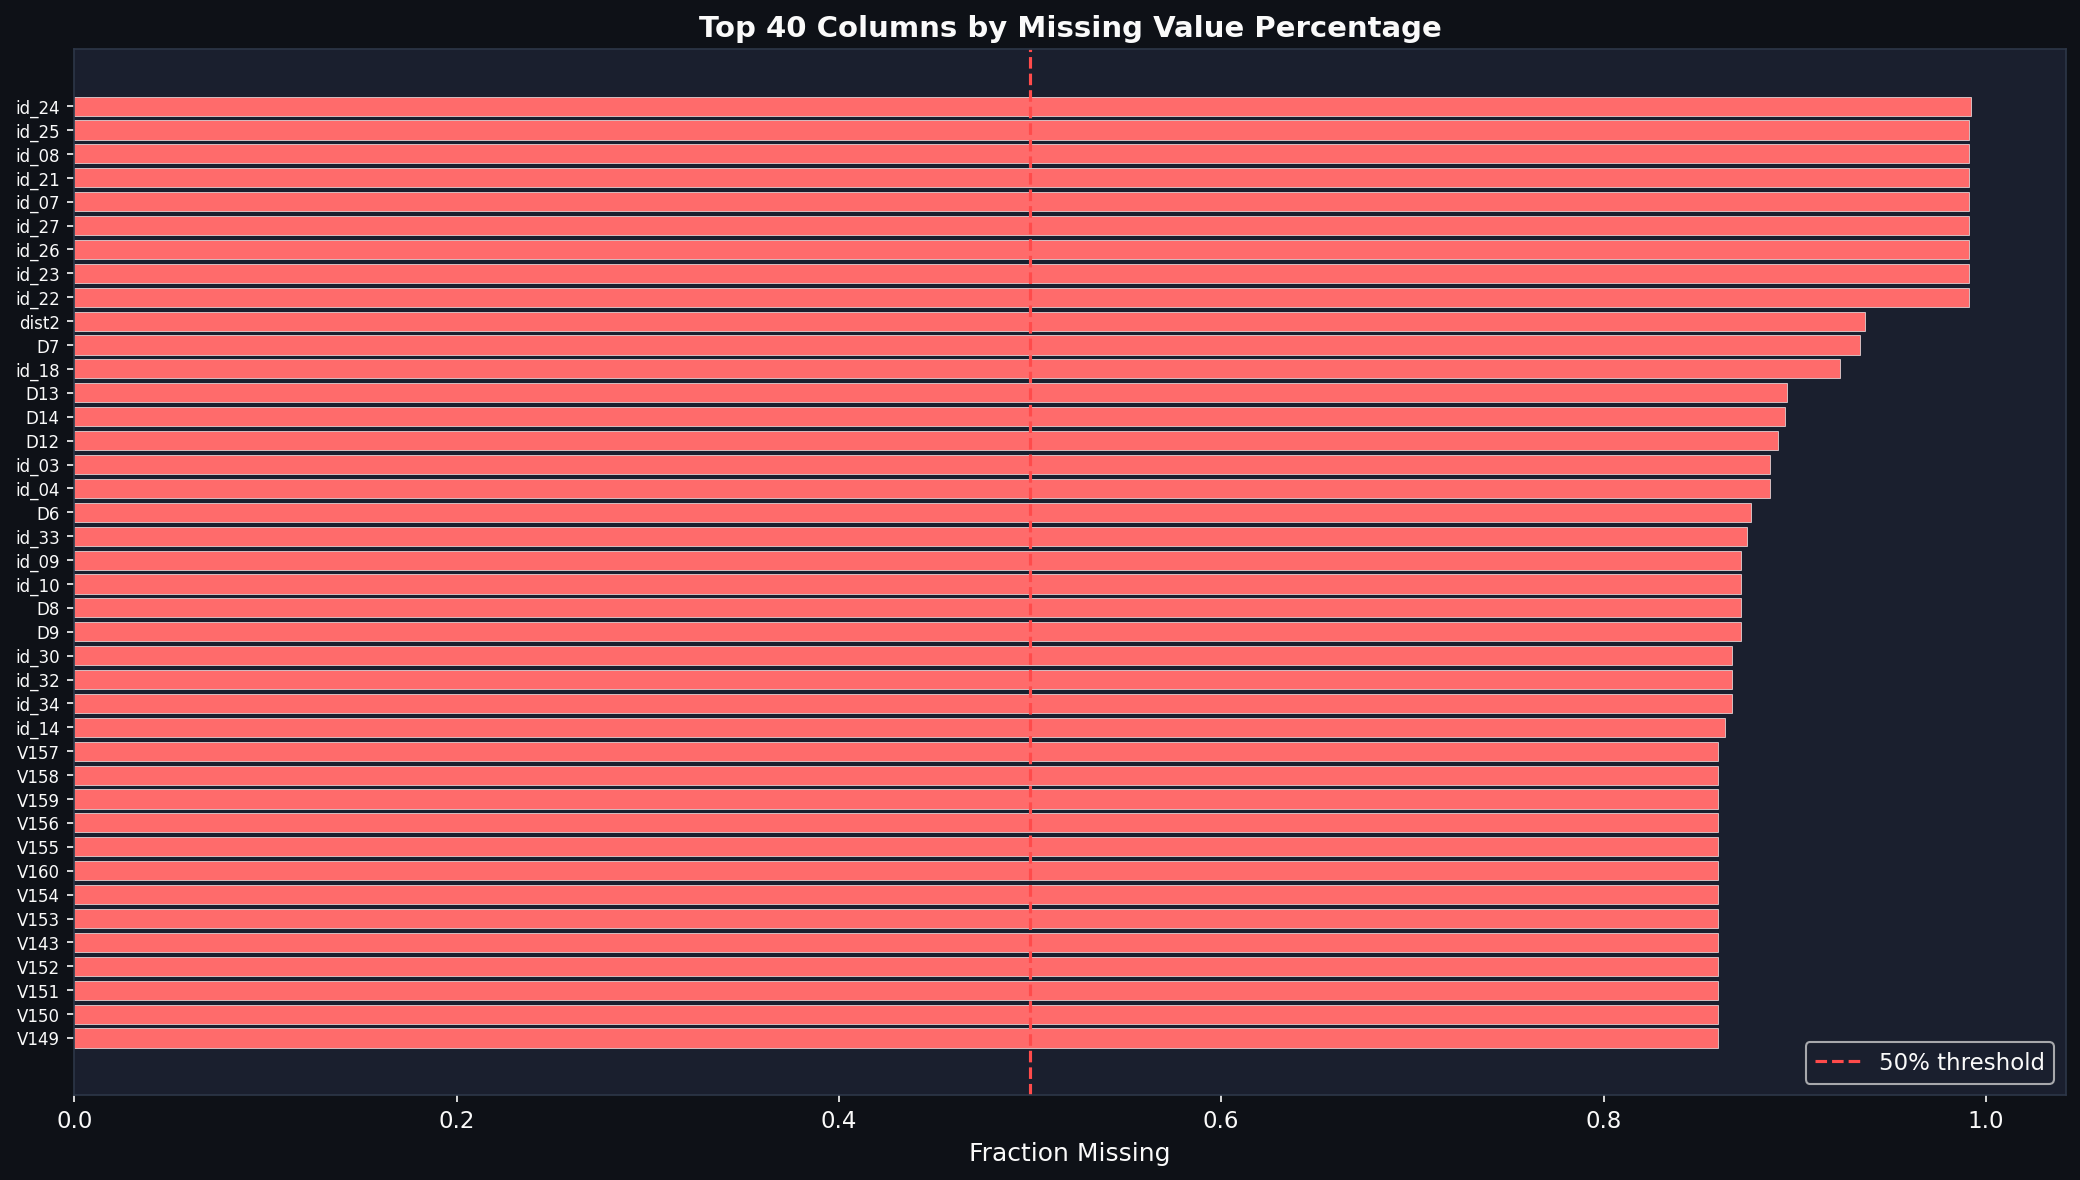


════════════════════════════════════════════════════════════
  Temporal Patterns
════════════════════════════════════════════════════════════


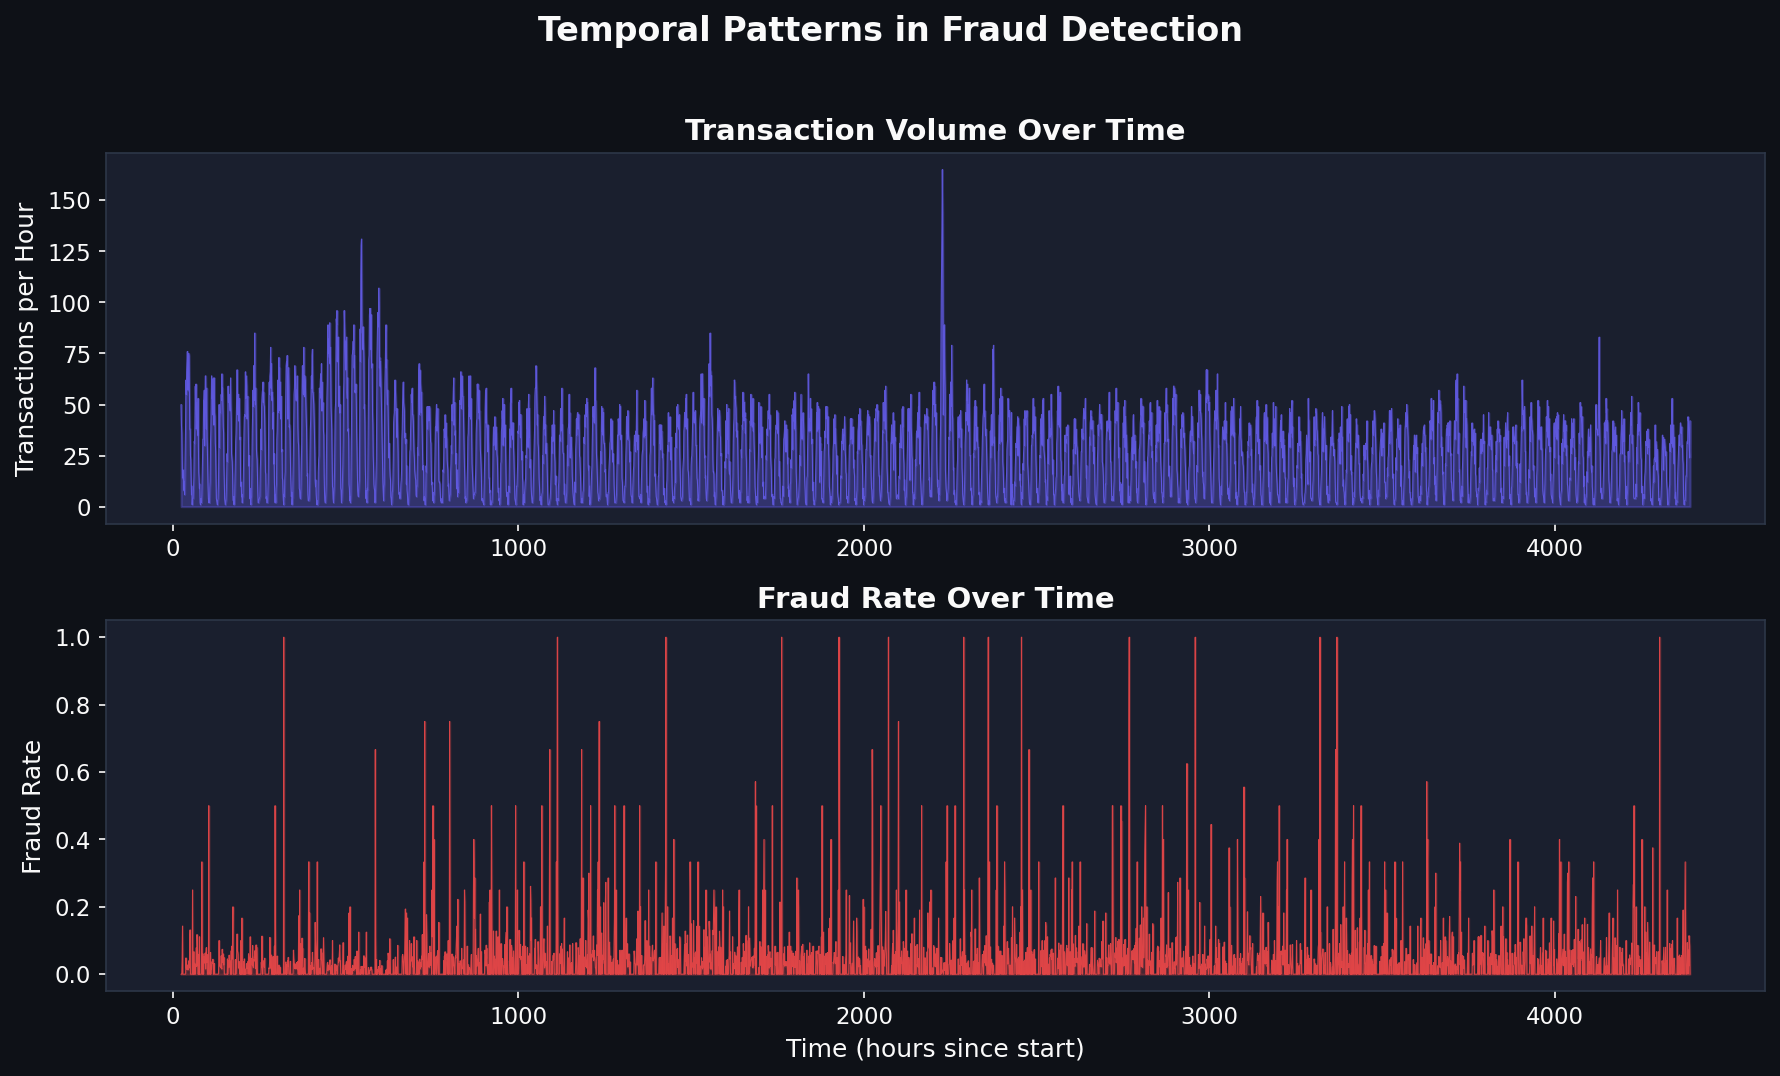


════════════════════════════════════════════════════════════
  Product Analysis
════════════════════════════════════════════════════════════


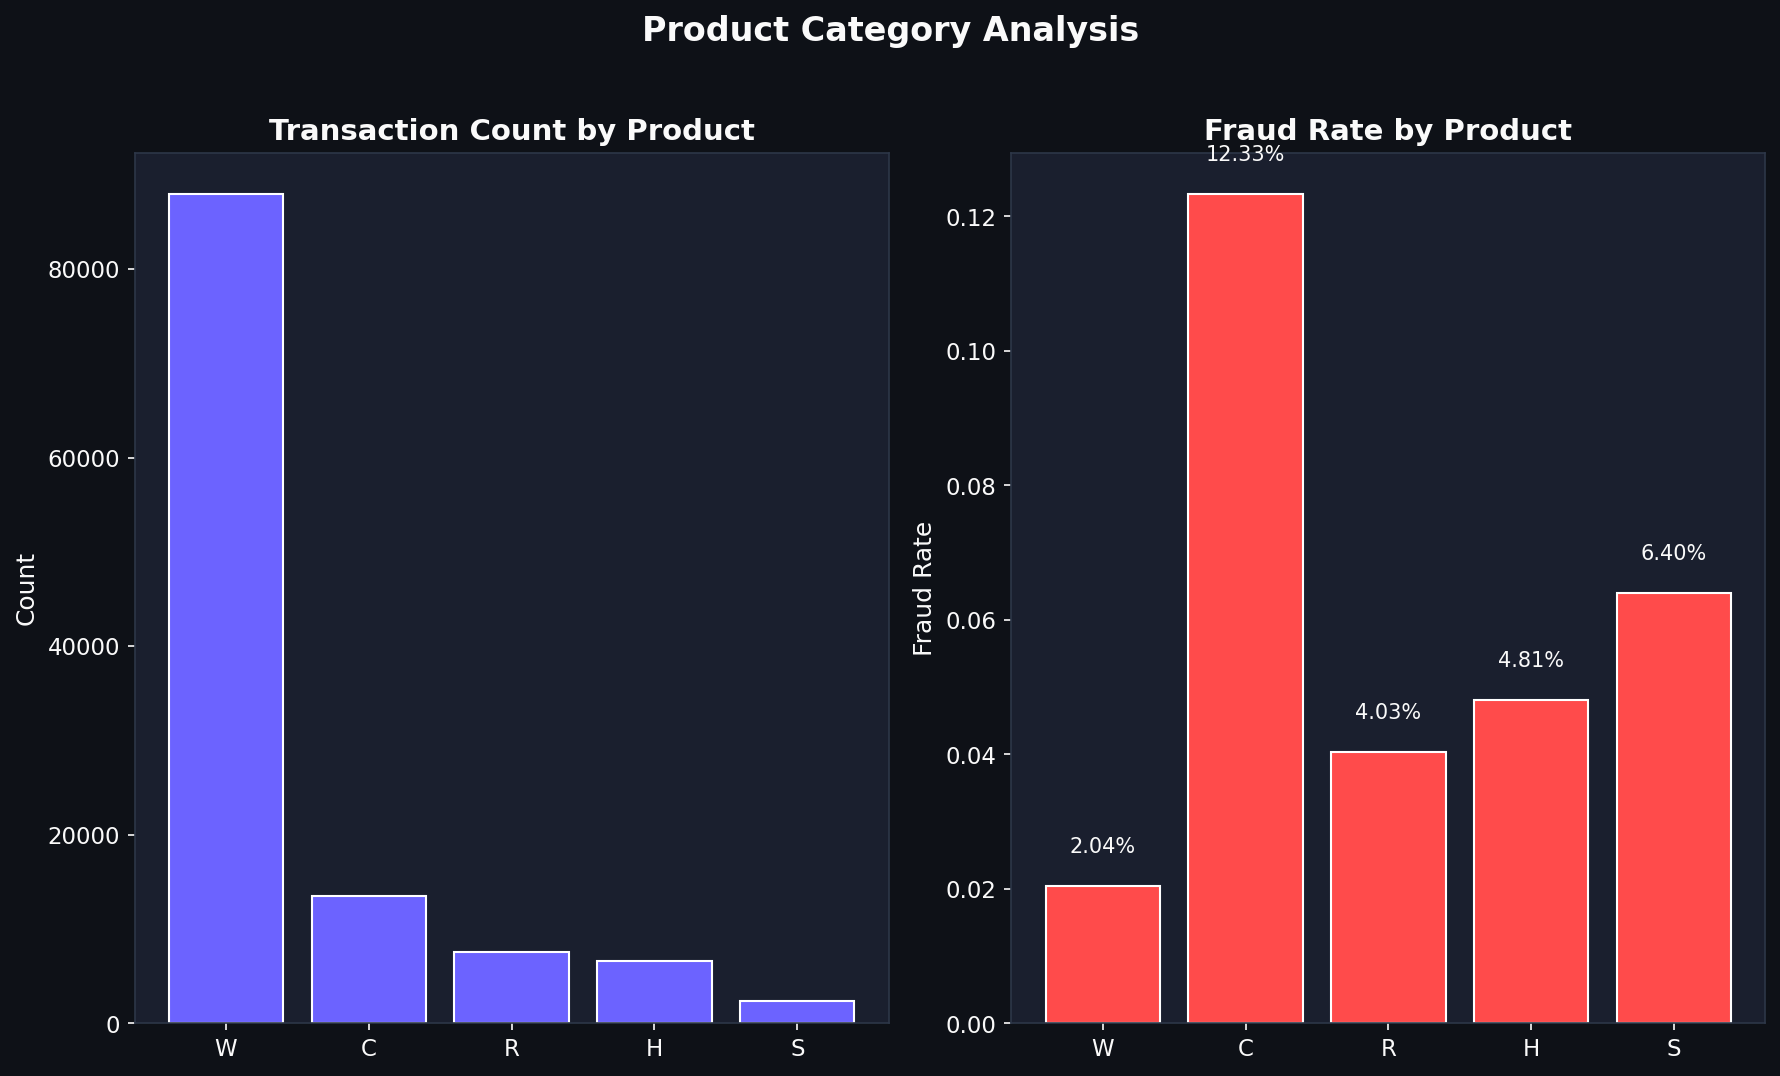


════════════════════════════════════════════════════════════
  Card Type Analysis
════════════════════════════════════════════════════════════


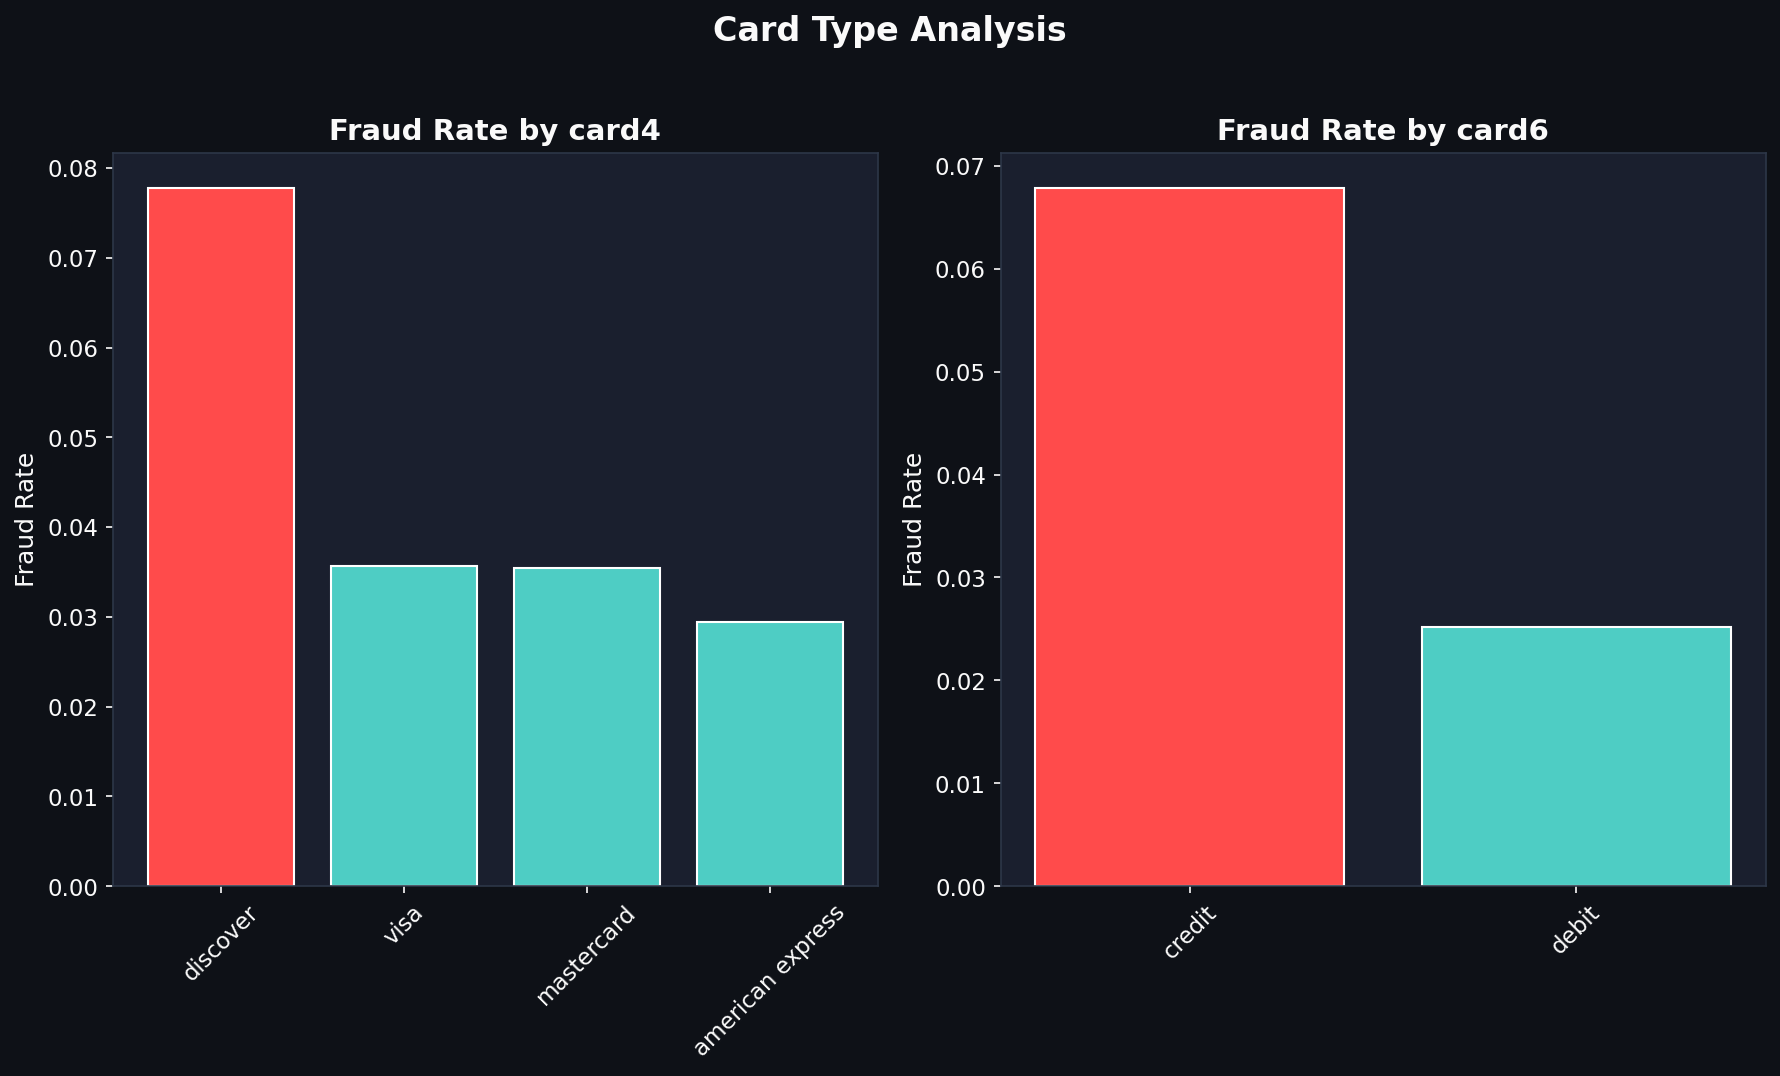


════════════════════════════════════════════════════════════
  Email Domain Analysis
════════════════════════════════════════════════════════════


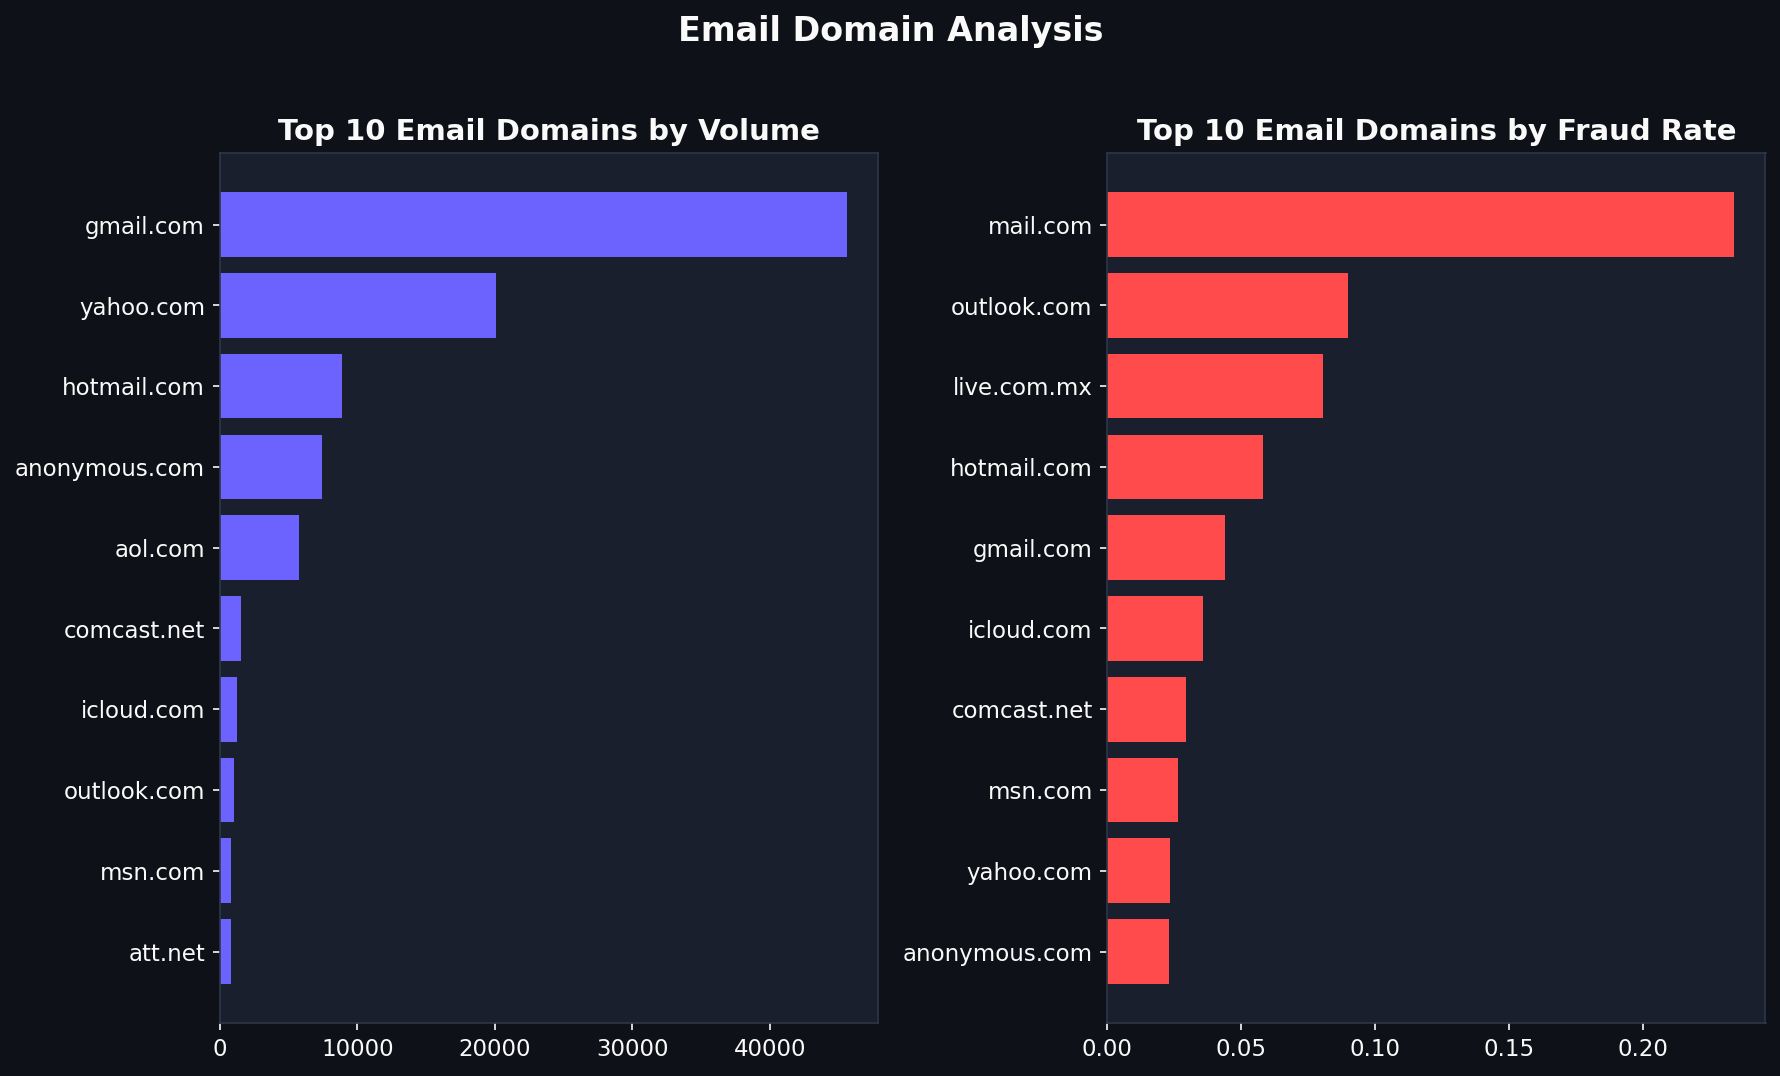


════════════════════════════════════════════════════════════
  Feature Distributions (V1-V10)
════════════════════════════════════════════════════════════


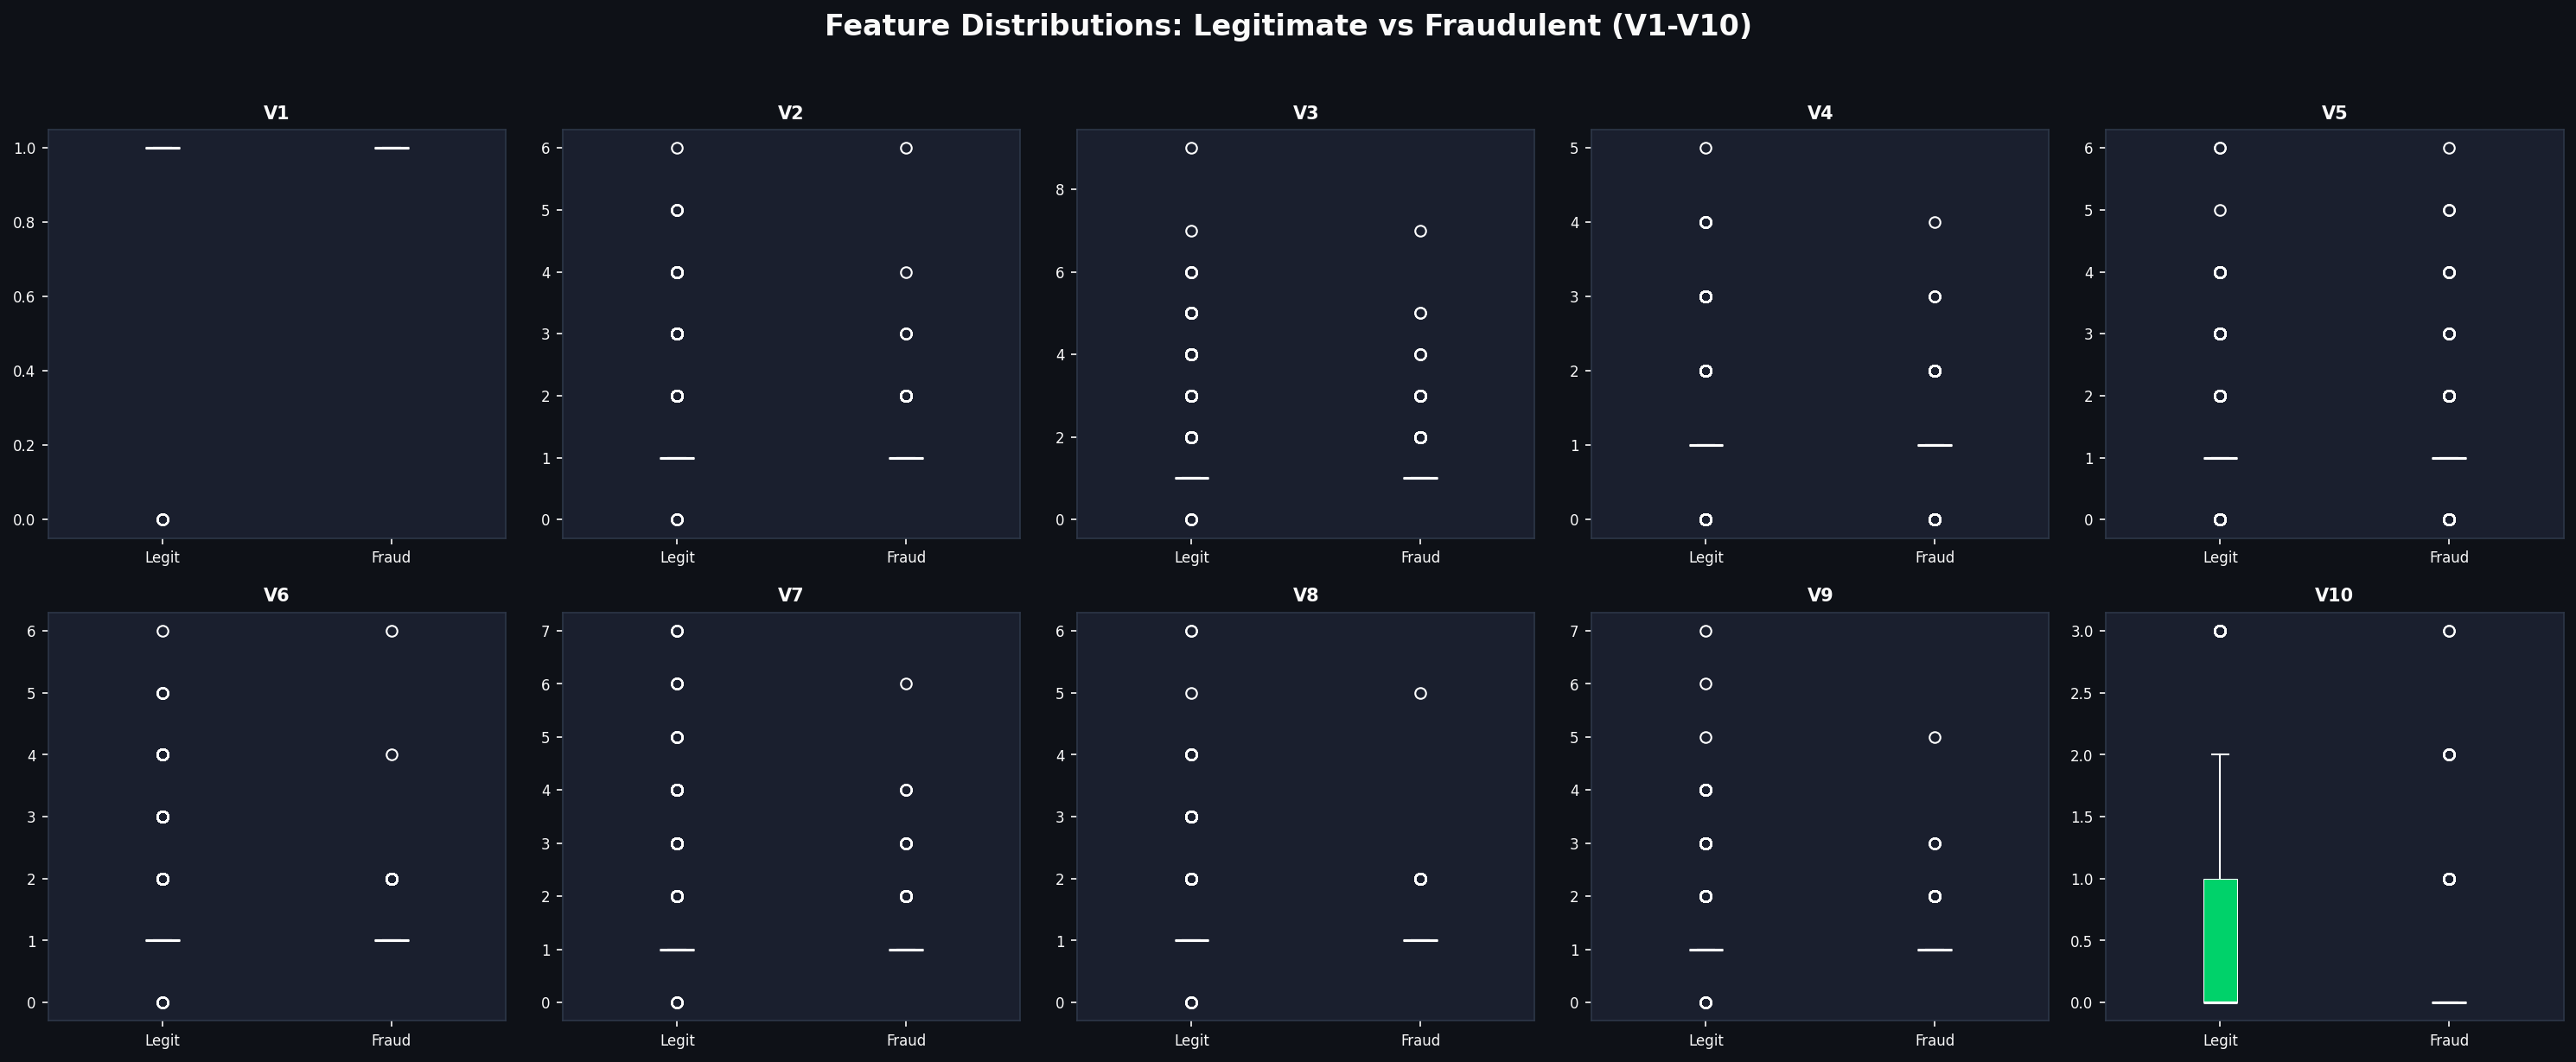


════════════════════════════════════════════════════════════
  Transaction Amount by Class
════════════════════════════════════════════════════════════


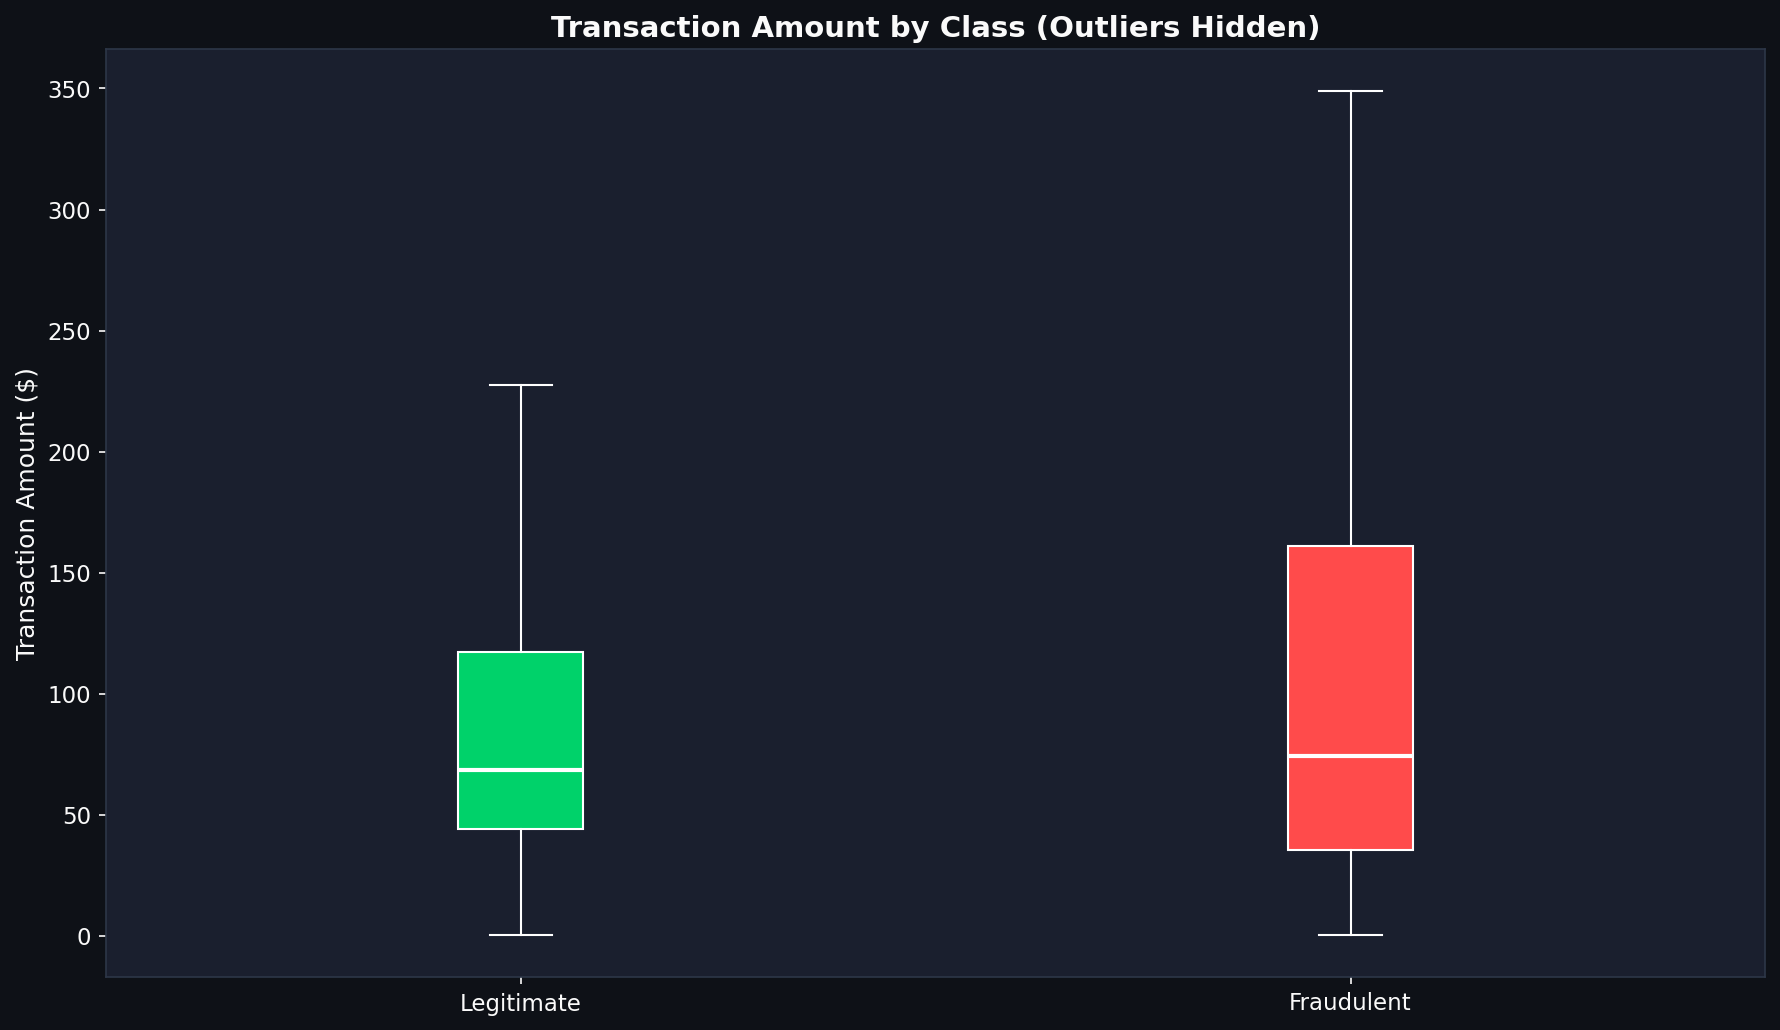

In [11]:
# Display key EDA plots inline
from IPython.display import Image, display

eda_plots = [
    ('Class Distribution', '01_class_distribution.png'),
    ('Transaction Amount Distribution', '02_transaction_amount.png'),
    ('Correlation Heatmap', '03_correlation_heatmap.png'),
    ('Missing Values', '04_missing_values.png'),
    ('Temporal Patterns', '05_time_pattern.png'),
    ('Product Analysis', '06_product_analysis.png'),
    ('Card Type Analysis', '07_card_analysis.png'),
    ('Email Domain Analysis', '08_email_analysis.png'),
    ('Feature Distributions (V1-V10)', '09_feature_distributions.png'),
    ('Transaction Amount by Class', '10_amount_boxplot.png'),
]

for title, filename in eda_plots:
    path = os.path.join(eda_dir, filename)
    if os.path.exists(path):
        print(f'\n{"═"*60}')
        print(f'  {title}')
        print(f'{"═"*60}')
        display(Image(filename=path, width=900))

### EDA Key Findings

1. **Severe Class Imbalance**: Only ~3.5% of transactions are fraudulent (ratio ~1:28)
2. **Transaction Amount**: Fraudulent transactions tend to have different amount distributions
3. **Temporal Patterns**: Fraud rates vary over time — cyclical patterns observed
4. **Product Categories**: Different products have significantly different fraud rates
5. **Missing Values**: Many identity and V-features have substantial missing data
6. **Feature Correlations**: Several V-features are highly correlated — PCA will help

---
## <b><font color='#FF4B4B'>Stage 5: Feature Engineering & Selection</font></b>

We engineer domain-specific features and reduce dimensionality:
- **Temporal features**: Hour, day-of-week with cyclical encoding
- **Amount features**: Log-transform, decimal/round indicators
- **Interaction features**: Card combinations, email matching, address risk
- **PCA**: V1-V339 reduced to 50 principal components (preserving ~85% variance)
- **Feature selection**: Mutual information and correlation-based filtering

**Note**: Feature engineering is applied BEFORE the train/val/test split in the preprocessing pipeline to ensure consistent feature schemas. SMOTE is applied AFTER the split (train only).

In [16]:
# ════════════════════════════════════════════════════════════════
# STAGE 5: FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════════

# Feature engineering was integrated into the preprocessing pipeline.
# Here we demonstrate the feature engineering concepts on sampled raw data for local testing.

from src.feature_engineering import (
    create_time_features, create_amount_features,
    create_card_features, create_email_features,
    create_c_d_aggregates, apply_pca_to_v_features,
    select_features_mi, drop_high_correlation,
    run_feature_engineering
)

# Run feature engineering on sampled dataset for local stability
df_fe = load_raw_data(sample_frac=sample_frac)
df_fe, pca = run_feature_engineering(df_fe)

print(f'\nFeature Engineering Results:')
print(f'   Final feature count: {df_fe.shape[1]}')
print(f'   Dataset shape: {df_fe.shape}')
if pca is not None:
    print(f'   PCA variance explained: {pca.explained_variance_ratio_.sum():.1%}')

2026-04-10 16:36:29 | DataLoader           | INFO    | ⏳ Starting: Loading transaction data
2026-04-10 16:36:33 | DataLoader           | INFO    |   Transactions: 590,540 rows × 394 cols
2026-04-10 16:36:33 | DataLoader           | INFO    | ✅ Finished: Loading transaction data (3.8s)
2026-04-10 16:36:33 | DataLoader           | INFO    | ⏳ Starting: Loading identity data
2026-04-10 16:36:33 | DataLoader           | INFO    |   Identity:     144,233 rows × 41 cols
2026-04-10 16:36:33 | DataLoader           | INFO    | ✅ Finished: Loading identity data (0.2s)
2026-04-10 16:36:33 | DataLoader           | INFO    | ⏳ Starting: Merging datasets on TransactionID
2026-04-10 16:36:33 | DataLoader           | INFO    |   Merged:       590,540 rows × 434 cols
2026-04-10 16:36:33 | DataLoader           | INFO    | ✅ Finished: Merging datasets on TransactionID (0.1s)
2026-04-10 16:36:33 | DataLoader           | INFO    | ⏳ Starting: Optimizing memory usage
2026-04-10 16:36:36 | DataLoader        

  Memory: 2567.1 MB → 1656.4 MB (35.5% reduction)


2026-04-10 16:36:36 | DataLoader           | INFO    |   Sampled: 590,540 → 118,108 rows (20.00%)
2026-04-10 16:36:36 | FeatureEng           | INFO    | ============================================================
2026-04-10 16:36:36 | FeatureEng           | INFO    |      FEATURE ENGINEERING
2026-04-10 16:36:36 | FeatureEng           | INFO    | ============================================================
2026-04-10 16:36:36 | FeatureEng           | INFO    | ⏳ Starting: Creating time features
2026-04-10 16:36:36 | FeatureEng           | INFO    |   ✅ Time features created (hour_of_day, day_of_week, cyclical)
2026-04-10 16:36:36 | FeatureEng           | INFO    | ✅ Finished: Creating time features (0.0s)
2026-04-10 16:36:36 | FeatureEng           | INFO    | ⏳ Starting: Creating amount features
2026-04-10 16:36:36 | FeatureEng           | INFO    |   ✅ Amount features created (log, decimal, is_round)
2026-04-10 16:36:36 | FeatureEng           | INFO    | ✅ Finished: Creating amount fe


Feature Engineering Results:
   Final feature count: 148
   Dataset shape: (118108, 148)
   PCA variance explained: 100.0%


In [17]:
# Re-run preprocessing on engineered features
from src.preprocessing import run_preprocessing_pipeline

prep_result = run_preprocessing_pipeline(df_fe)

X_train = prep_result['X_train']
X_val   = prep_result['X_val']
X_test  = prep_result['X_test']
y_train = prep_result['y_train']
y_val   = prep_result['y_val']
y_test  = prep_result['y_test']
feature_names = prep_result['feature_names']
hetero_data = prep_result['hetero_data']  # <--- ADD THIS LINE

print(f'\n✅ Preprocessing Complete (with engineered features)!')
print(f'   Train: {X_train.shape}')


2026-04-10 16:36:43 | Preprocessing        | INFO    | ============================================================
2026-04-10 16:36:43 | Preprocessing        | INFO    |      PREPROCESSING PIPELINE
2026-04-10 16:36:43 | Preprocessing        | INFO    | ============================================================
2026-04-10 16:36:43 | Preprocessing        | INFO    | ⏳ Starting: Handling missing values
2026-04-10 16:36:43 | Preprocessing        | INFO    |   Dropped 52 columns with >50% missing
2026-04-10 16:36:43 | Preprocessing        | INFO    |   Features: 148 → 96 (removed 52)
2026-04-10 16:36:43 | Preprocessing        | INFO    |   Remaining nulls: 0
2026-04-10 16:36:43 | Preprocessing        | INFO    | ✅ Finished: Handling missing values (0.1s)
2026-04-10 16:36:43 | Preprocessing        | INFO    | ⏳ Starting: Capping outliers
2026-04-10 16:36:43 | Preprocessing        | INFO    |   Capped 1,114 outliers in TransactionAmt at 1104.00
2026-04-10 16:36:43 | Preprocessing        | 


✅ Preprocessing Complete (with engineered features)!
   Train: (82674, 94)


In [6]:
# Feature selection using Mutual Information
from src.feature_engineering import select_features_mi

# Compute MI scores on a sample (full dataset is slow)
sample_idx = np.random.RandomState(42).choice(len(X_train), min(50000, len(X_train)), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

selected_features, mi_scores = select_features_mi(X_sample, y_sample, top_k=min(100, len(feature_names)))

# Plot MI scores
set_plot_style()
fig, ax = plt.subplots(figsize=(12, 8))
top_20 = mi_scores.head(20)
ax.barh(range(len(top_20)), top_20.values[::-1], color=COLORS['primary'])
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20.index[::-1])
ax.set_xlabel('Mutual Information Score')
ax.set_title('Top 20 Features by Mutual Information with isFraud', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(EDA_DIR, '11_mutual_information.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'\nTop 10 features: {selected_features[:10]}')

2026-04-10 15:10:30 | FeatureEng           | INFO    |   Computing mutual information for 94 features...
2026-04-10 15:10:36 | FeatureEng           | INFO    |   ✅ Selected top 94 features by Mutual Information
2026-04-10 15:10:36 | FeatureEng           | INFO    |   Top 10: ['V_PCA_3', 'V_PCA_8', 'V_PCA_4', 'card1', 'V_PCA_14', 'card2', 'V_PCA_9', 'C7', 'V_PCA_18', 'TransactionAmt_decimal']



Top 10 features: ['V_PCA_3', 'V_PCA_8', 'V_PCA_4', 'card1', 'V_PCA_14', 'card2', 'V_PCA_9', 'C7', 'V_PCA_18', 'TransactionAmt_decimal']


---
## <b><font color='#FF4B4B'>Stage 6: Model Building & Training</font></b>

We train local tabular baselines and the **DenseHGNN-ATT-TD** model (paper-style heterogeneous graph path):

| Model | Training Style | Key Hyperparameters |
|-------|----------------|--------------------|
| **Decision Tree** | `class_weight='balanced'` + SMOTE | `max_depth=12`, `min_samples_split=50` |
| **XGBoost** | `scale_pos_weight` + SMOTE | `n_estimators=500`, `max_depth=8`, `lr=0.05` |
| **DenseHGNN-ATT-TD** | Heterogeneous graph with temporal decay + relation attention | `hidden_dim`, `max_nodes`, `batch_size`, `epochs` |

### HGNN concept
DenseHGNN-ATT-TD models fraud as a multi-relation temporal graph (for example card, address, email links), applies time decay, and uses attention to fuse relation-specific views.

### SMOTE (Synthetic Minority Oversampling Technique)
SMOTE creates synthetic fraud samples by interpolating between existing minority samples and their k-nearest neighbors. **Applied ONLY to training data** — never to validation/test to prevent data leakage.

In [ ]:
import os
import importlib
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

# DenseHGNN mode: run dense heterogeneous graph training explicitly.
os.environ["BUILD_HETERO_GRAPH"] = "1"
os.environ["ALLOW_HGNN_FALLBACK"] = "0"
os.environ["USE_NEIGHBOR_SAMPLED_HGNN"] = "0"
os.environ["XGB_GPU_ID"] = "-1"

# Keep native thread counts low to avoid XGBoost/OpenMP instability on macOS.
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ["XGB_N_JOBS"] = "1"

# Keep more sparse identity/device columns for stronger relation construction.
import src.preprocessing as preprocessing_module
import src.config as config_module
preprocessing_module.MISSING_THRESHOLD = 0.90

# Baseline NN params retained for consistency in other notebook cells/config reads.
config_module.NN_PARAMS.update({
    'hidden_dims': [384, 192, 96],
    'dropout_rates': [0.20, 0.20, 0.15],
    'learning_rate': 5e-4,
    'weight_decay': 5e-5,
    'max_epochs': 70,
    'patience': 15,
    'focal_gamma': 1.5,
    'focal_alpha': 0.85,
})

# Rebuild preprocessing output for baseline models.
from src.preprocessing import run_preprocessing_pipeline
prep_result = run_preprocessing_pipeline(df_fe)

X_train = prep_result['X_train']
X_val   = prep_result['X_val']
X_test  = prep_result['X_test']
y_train = prep_result['y_train']
y_val   = prep_result['y_val']
y_test  = prep_result['y_test']
feature_names = prep_result['feature_names']
hetero_data = prep_result['hetero_data']

import src.training as training_module
importlib.reload(training_module)

print("\nTraining tabular baselines (Decision Tree + XGBoost)...")
models = {}
models["Decision Tree"] = training_module.train_decision_tree(X_train, y_train, X_val, y_val)
models["XGBoost"] = training_module.train_xgboost(X_train, y_train, X_val, y_val)

print("\nTraining DenseHGNN-ATT-TD...")
train_file = os.path.join(DATA_DIR, "train_processed.csv")
if os.path.exists(train_file):
    df_train = pd.read_csv(train_file)
else:
    # Fallback to engineered dataframe if processed artifact is unavailable.
    df_train = df_fe.copy()

if TARGET_COL not in df_train.columns:
    raise RuntimeError(f"{TARGET_COL} not found in DenseHGNN training dataframe.")

required_rel_candidates = ['card1', 'addr1', 'P_emaildomain']
relations = [c for c in required_rel_candidates if c in df_train.columns]
if 'TransactionDT' not in df_train.columns or len(relations) < 2:
    raise RuntimeError(
        "DenseHGNN-ATT-TD requires TransactionDT and at least two relation columns from "
        f"{required_rel_candidates}. Found relations={relations}."
    )

feature_cols_hgnn = [
    c for c in df_train.columns
    if c not in [TARGET_COL, 'TransactionID', 'TransactionDT']
]
X_hgnn = df_train[feature_cols_hgnn].fillna(0).values
y_hgnn = df_train[TARGET_COL].values

train_indices, val_indices = train_test_split(
    np.arange(len(y_hgnn)),
    test_size=0.3,
    random_state=RANDOM_STATE,
    stratify=y_hgnn,
)

dense_hidden_dim = 96 if torch.cuda.is_available() else 64
dense_max_nodes = min(len(df_train), 9000 if torch.cuda.is_available() else 2800)
dense_batch_size = 1024 if torch.cuda.is_available() else 512
dense_epochs = 18 if torch.cuda.is_available() else 12
dense_lr = 5e-4

dense_hgnn_model, nn_history = training_module.train_dense_hgnn_att_td(
    df=df_train,
    y=y_hgnn,
    X_features=X_hgnn,
    relations=relations,
    train_indices=train_indices,
    val_indices=val_indices,
    hidden_dim=dense_hidden_dim,
    max_nodes=dense_max_nodes,
    batch_size=dense_batch_size,
    num_epochs=dense_epochs,
    learning_rate=dense_lr,
)

# Keep DenseHGNN artifacts separately to avoid Stage 7 interface mismatch with generic evaluator.
dense_hgnn_artifacts = {
    'model': dense_hgnn_model,
    'history': nn_history,
    'relations': relations,
    'feature_columns': feature_cols_hgnn,
}

print("\n✅ DenseHGNN-ATT-TD training completed successfully.")
print("ℹ️ Stage 7 currently evaluates baseline models from models; DenseHGNN metrics are logged in Stage 6/6b outputs.")

2026-04-10 18:07:54 | Preprocessing        | INFO    | ============================================================
2026-04-10 18:07:54 | Preprocessing        | INFO    |      PREPROCESSING PIPELINE
2026-04-10 18:07:54 | Preprocessing        | INFO    | ============================================================
2026-04-10 18:07:54 | Preprocessing        | INFO    | ⏳ Starting: Handling missing values
2026-04-10 18:07:54 | Preprocessing        | INFO    |   Dropped 11 columns with >90% missing
2026-04-10 18:07:54 | Preprocessing        | INFO    |   Features: 148 → 137 (removed 11)
2026-04-10 18:07:54 | Preprocessing        | INFO    |   Remaining nulls: 0
2026-04-10 18:07:54 | Preprocessing        | INFO    | ✅ Finished: Handling missing values (0.3s)
2026-04-10 18:07:54 | Preprocessing        | INFO    | ⏳ Starting: Capping outliers
2026-04-10 18:07:54 | Preprocessing        | INFO    |   Capped 1,114 outliers in TransactionAmt at 1104.00
2026-04-10 18:07:54 | Preprocessing        |


Training tabular baselines (Decision Tree + XGBoost)...


2026-04-10 18:07:55 | Training             | INFO    |   SMOTE Resampling:
2026-04-10 18:07:55 | Training             | INFO    |     Before: 79,704 legit, 2,970 fraud (ratio 1:26.8)
2026-04-10 18:07:55 | Training             | INFO    |     After:  79,704 legit, 39,852 fraud (ratio 1:2.0)
2026-04-10 18:07:55 | Training             | INFO    |     Synthetic samples created: 36,882
2026-04-10 18:07:55 | Training             | INFO    | ⏳ Starting: Decision Tree training
2026-04-10 18:07:55 | Models               | INFO    |   🌳 Decision Tree created (max_depth=12, class_weight=balanced)
2026-04-10 18:08:00 | Training             | INFO    | ✅ Finished: Decision Tree training (4.8s)
2026-04-10 18:08:00 | Training             | INFO    |   Val Accuracy: 0.9040
2026-04-10 18:08:00 | Training             | INFO    |   Val F1-Score: 0.2868
2026-04-10 18:08:00 | Training             | INFO    |   Val ROC-AUC:  0.8066
2026-04-10 18:08:00 | Training             | INFO    |   Model saved → /User


Training DenseHGNN-ATT-TD (not FraudNet)...


2026-04-10 18:08:23 | Training             | INFO    | ============================================================
2026-04-10 18:08:23 | Training             | INFO    |   🧠 Training DenseHGNN-ATT-TD (Heterogeneous Graph NN)
2026-04-10 18:08:23 | Training             | INFO    | ============================================================
2026-04-10 18:08:23 | Training             | WARNING |   MPS detected, but using CPU for DenseHGNN stability.
2026-04-10 18:08:23 | Training             | INFO    |   📍 Device: cpu
2026-04-10 18:08:23 | Training             | INFO    |   📉 Sampling down to 2800 from 590540 nodes (memory safety)
2026-04-10 18:08:24 | Training             | INFO    |   📐 Estimated dense graph memory: ~0.18 GB
2026-04-10 18:08:24 | Training             | INFO    | 
  🔗 Building 3 relation views...
2026-04-10 18:08:24 | Training             | INFO    | ⏳ Starting: Graph construction
2026-04-10 18:08:24 | HGNN_Utils           | INFO    |   🔗 Building card1 adjacency matri


✅ DenseHGNN-ATT-TD training completed successfully.
ℹ️ Stage 7 currently evaluates baseline models from `models`; DenseHGNN metrics are logged in Stage 6/6b outputs.


In [ ]:
# DenseHGNN training curves
if 'nn_history' in globals() and nn_history:
    set_plot_style()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curve
    axes[0].plot(nn_history['train_losses'], color=COLORS['fraud'], linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Focal Loss')
    axes[0].set_title('Training Loss (Focal Loss)', fontweight='bold')
    axes[0].grid(alpha=0.3)
    
    # Validation AUC curve
    axes[1].plot(nn_history['val_aucs'], color=COLORS['legit'], linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('ROC-AUC')
    axes[1].set_title('Validation ROC-AUC', fontweight='bold')
    axes[1].grid(alpha=0.3)
    
    fig.suptitle('DenseHGNN-ATT-TD Training Curves', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(EVAL_DIR, '06_dense_hgnn_training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipping training curves: nn_history is not available yet.')

In [19]:
# Cross-validation (on a sample for speed)
print('Running 5-fold stratified cross-validation...')
sample_size = min(100000, len(X_train))
cv_idx = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
X_cv = X_train.iloc[cv_idx]
y_cv = y_train.iloc[cv_idx]

cv_results = training_module.cross_validate_models(X_cv, y_cv, n_folds=5)

# Display CV results
for model_name, folds in cv_results.items():
    if folds:
        f1s = [f['f1'] for f in folds]
        aucs = [f['auc'] for f in folds]
        print(f'\n{model_name}:')
        print(f'  F1:  {np.mean(f1s):.4f} ± {np.std(f1s):.4f}')
        print(f'  AUC: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}')

2026-04-10 15:06:32 | Training             | INFO    | ============================================================
2026-04-10 15:06:32 | Training             | INFO    |      5-FOLD STRATIFIED CROSS-VALIDATION
2026-04-10 15:06:32 | Training             | INFO    | ============================================================
2026-04-10 15:06:32 | Training             | INFO    | 
  ── Fold 1/5 ──
2026-04-10 15:06:32 | Models               | INFO    |   🌳 Decision Tree created (max_depth=12, class_weight=balanced)


Running 5-fold stratified cross-validation...


2026-04-10 15:06:36 | Models               | INFO    |   🚀 XGBoost created (n_estimators=500, max_depth=8, scale_pos_weight=26.8)
2026-04-10 15:06:47 | Training             | INFO    |     Decision Tree        | F1: 0.3158 | AUC: 0.8057 | AUPRC: 0.3466
2026-04-10 15:06:47 | Training             | INFO    |     XGBoost              | F1: 0.5669 | AUC: 0.9051 | AUPRC: 0.5971
2026-04-10 15:06:47 | Training             | INFO    | 
  ── Fold 2/5 ──
2026-04-10 15:06:47 | Models               | INFO    |   🌳 Decision Tree created (max_depth=12, class_weight=balanced)
2026-04-10 15:06:50 | Models               | INFO    |   🚀 XGBoost created (n_estimators=500, max_depth=8, scale_pos_weight=26.8)
2026-04-10 15:07:02 | Training             | INFO    |     Decision Tree        | F1: 0.3011 | AUC: 0.7990 | AUPRC: 0.3303
2026-04-10 15:07:02 | Training             | INFO    |     XGBoost              | F1: 0.5562 | AUC: 0.8963 | AUPRC: 0.5769
2026-04-10 15:07:02 | Training             | INFO    | 



Decision Tree:
  F1:  0.3001 ± 0.0149
  AUC: 0.7933 ± 0.0163

XGBoost:
  F1:  0.5452 ± 0.0224
  AUC: 0.8968 ± 0.0082


---
## <b><font color='#FF4B4B'>Stage 7: Model Evaluation & Comparison</font></b>

We evaluate all three models on the **held-out test set** using:
- Precision-Recall Curves (primary — better suited for imbalanced data than ROC)
- ROC Curves
- Confusion Matrices at optimal thresholds
- Cost-Benefit Analysis (FN=$500, FP=$10)

In [23]:
# ════════════════════════════════════════════════════════════════
# STAGE 7: EVALUATION
# ════════════════════════════════════════════════════════════════

import importlib
import src.evaluation as evaluation_module
importlib.reload(evaluation_module)

eval_results, eval_probas, comparison_df = evaluation_module.run_evaluation_pipeline(
    models, X_test, y_test, hetero_data=hetero_data
)

# Display comparison table
print('\n' + '═'*80)
print('  MODEL COMPARISON (OPTIMAL THRESHOLDS)')
print('═'*80)
display(comparison_df.round(4))


2026-04-10 17:59:19 | Evaluation           | INFO    | ============================================================
2026-04-10 17:59:19 | Evaluation           | INFO    |      EVALUATION PIPELINE
2026-04-10 17:59:19 | Evaluation           | INFO    | ============================================================
2026-04-10 17:59:19 | Evaluation           | INFO    | ============================================================
2026-04-10 17:59:19 | Evaluation           | INFO    |      MODEL EVALUATION ON TEST SET
2026-04-10 17:59:19 | Evaluation           | INFO    | ============================================================
2026-04-10 17:59:19 | Evaluation           | INFO    | 
  📊 Evaluating: Decision Tree
2026-04-10 17:59:19 | Evaluation           | INFO    |   Optimal threshold (max F1): 0.8852 → F1=0.3513
2026-04-10 17:59:19 | Evaluation           | INFO    |     @ threshold=0.50: Precision=0.2097, Recall=0.4764, F1=0.2912
2026-04-10 17:59:19 | Evaluation           | INFO    |   


════════════════════════════════════════════════════════════════════════════════
  MODEL COMPARISON (OPTIMAL THRESHOLDS)
════════════════════════════════════════════════════════════════════════════════


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,AUPRC,Threshold,FN (Missed),FP (False Alarm),Total Cost ($)
0,Decision Tree,0.9585,0.4004,0.3129,0.3513,0.7974,0.2942,0.89,437,298,"$121,980"
1,XGBoost,0.9732,0.6825,0.4733,0.5590,0.8953,0.5496,0.68,335,140,"$18,400"
2,Neural Network,0.9511,0.3263,0.3412,0.3336,0.8414,0.2931,0.53,419,448,"$105,480"



════════════════════════════════════════════════════════════
  Precision-Recall Curves
════════════════════════════════════════════════════════════


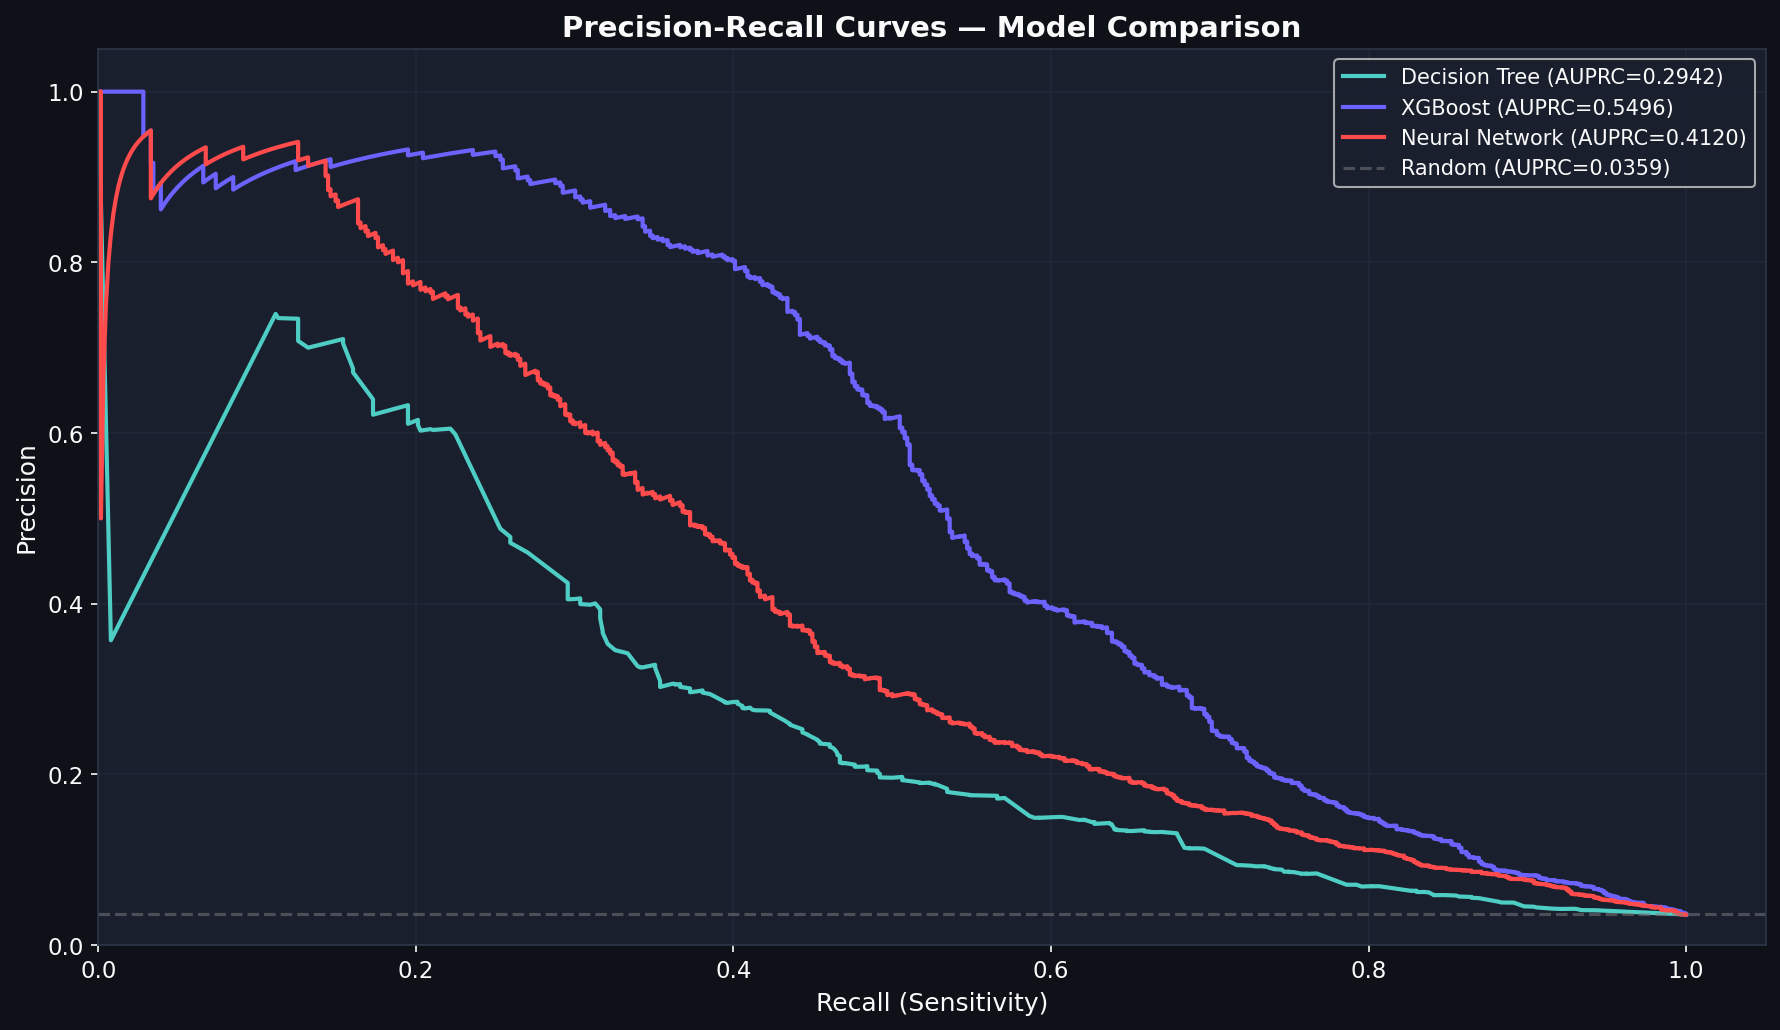


════════════════════════════════════════════════════════════
  ROC Curves
════════════════════════════════════════════════════════════


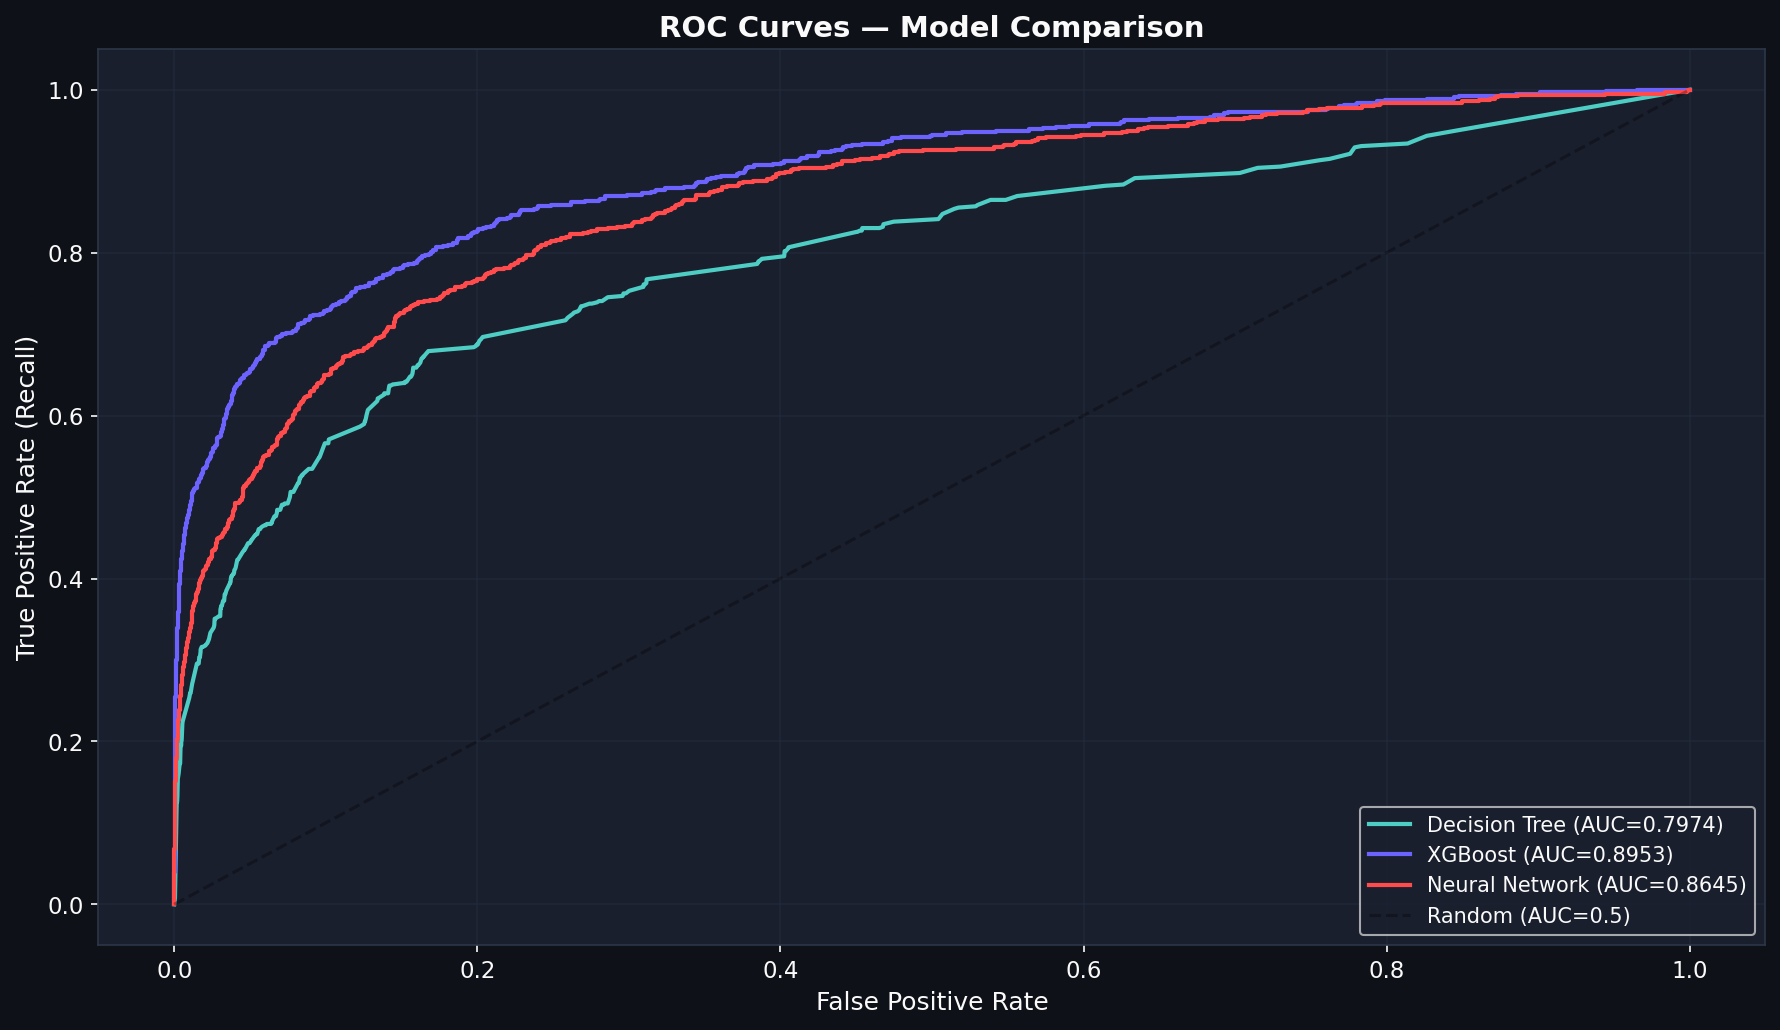


════════════════════════════════════════════════════════════
  Confusion Matrices
════════════════════════════════════════════════════════════


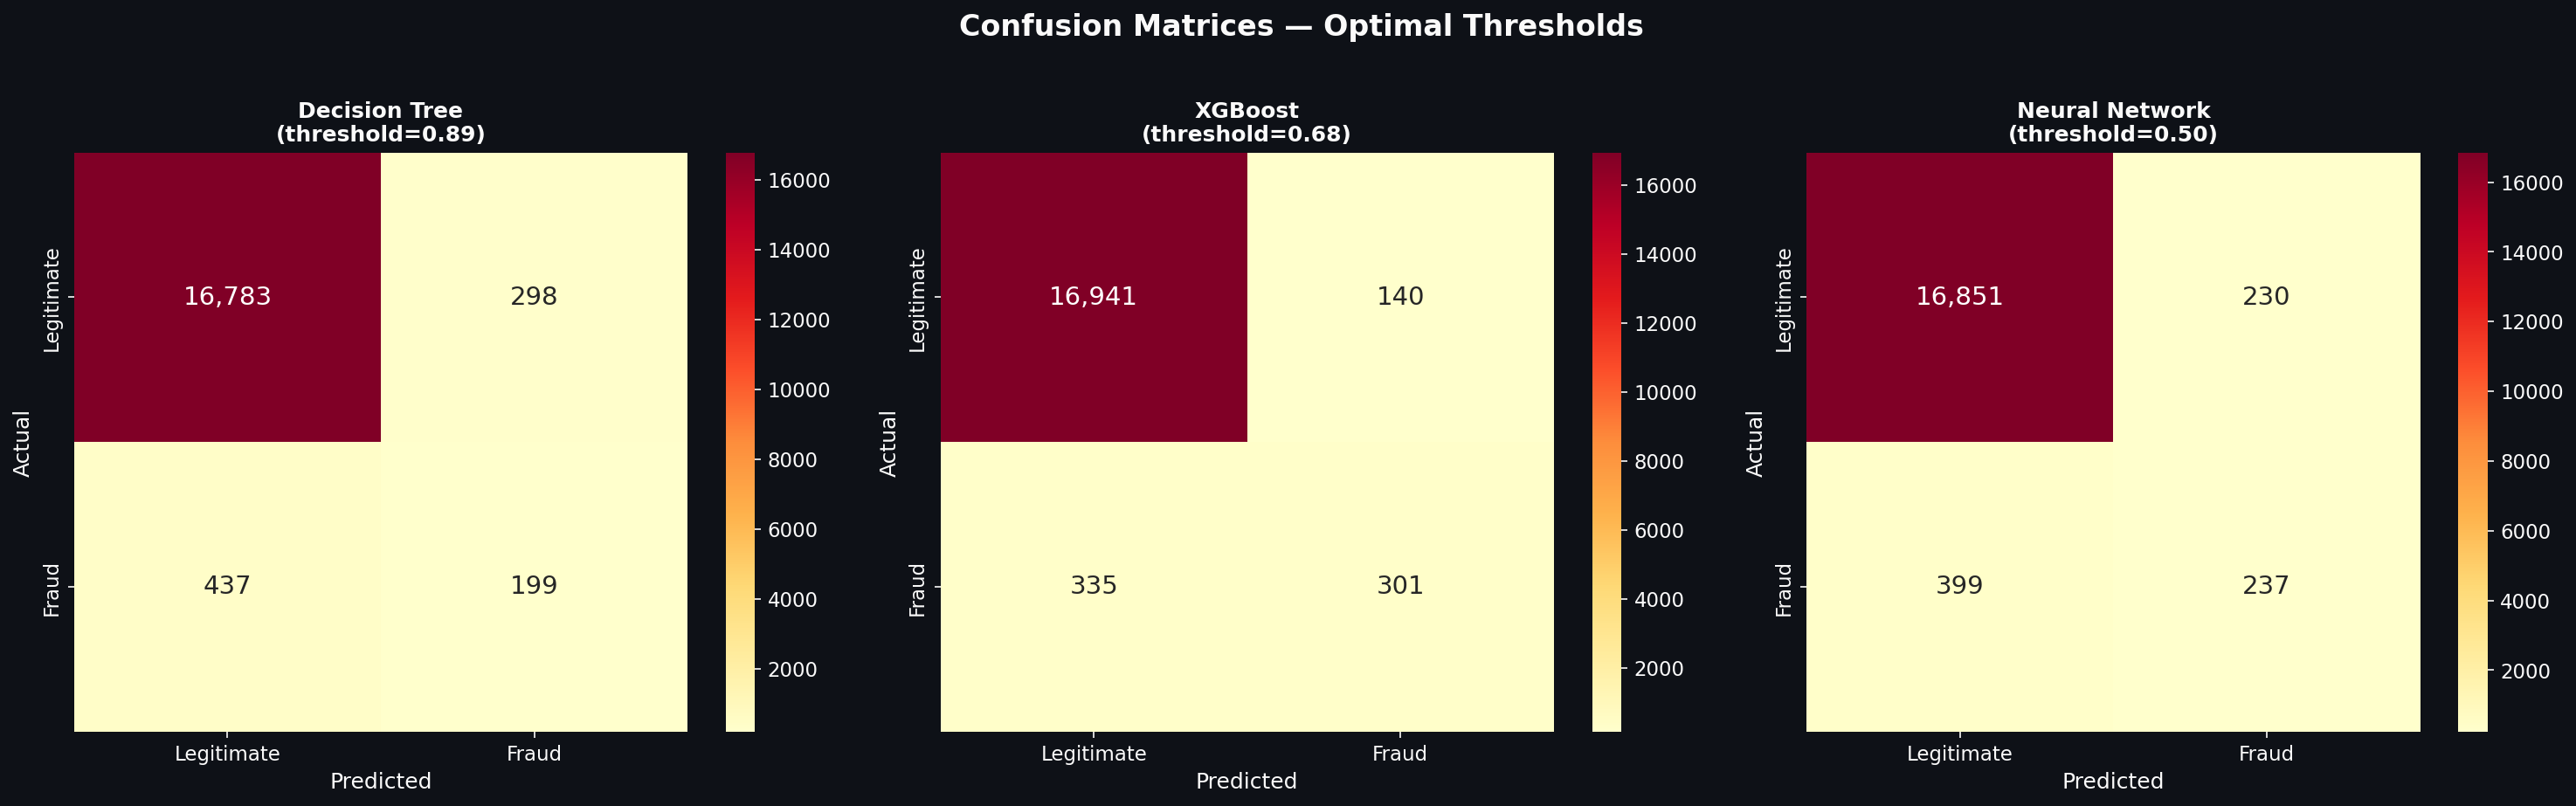


════════════════════════════════════════════════════════════
  Cost-Benefit Analysis
════════════════════════════════════════════════════════════


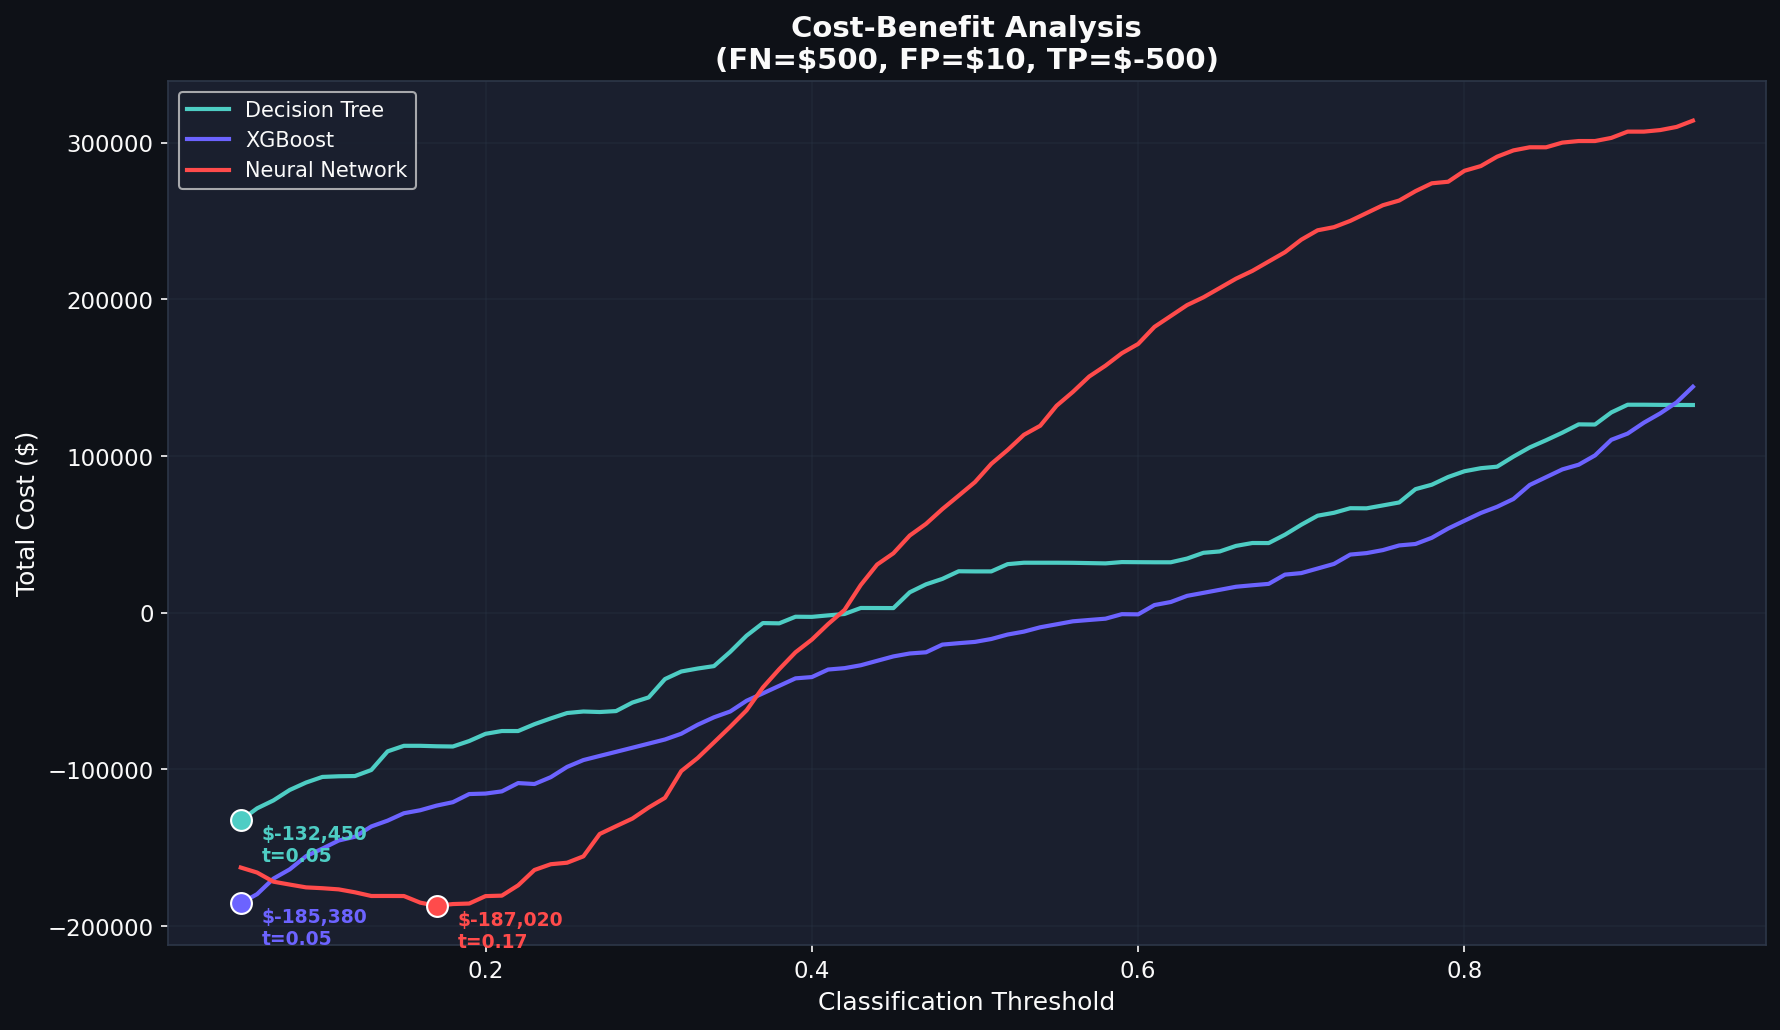


════════════════════════════════════════════════════════════
  Model Comparison Table
════════════════════════════════════════════════════════════


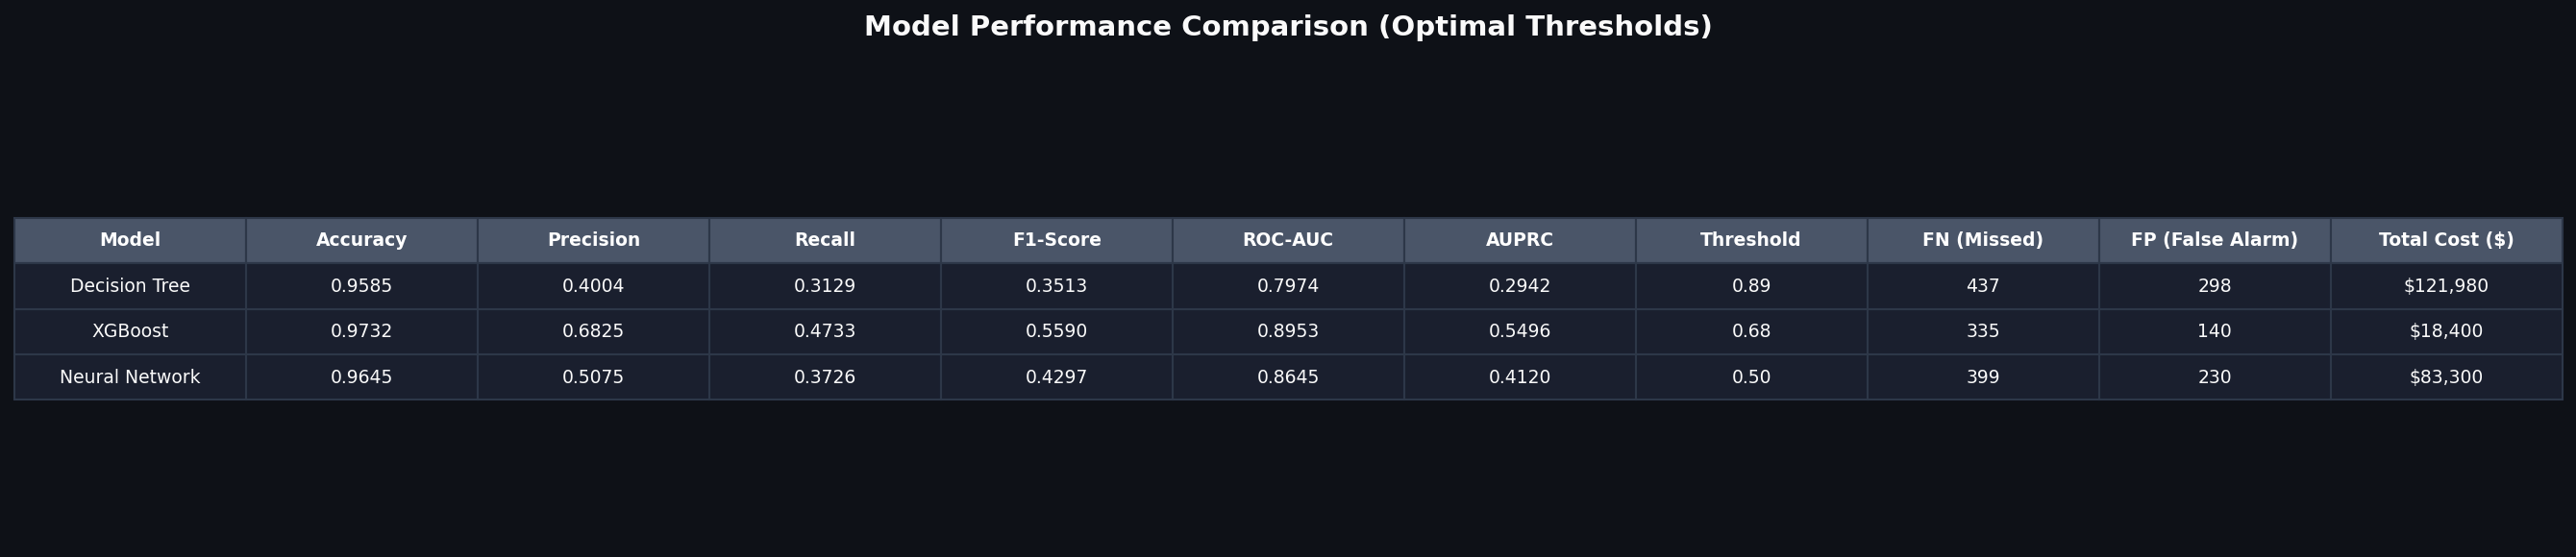

In [21]:
# Display evaluation plots
eval_plots = [
    ('Precision-Recall Curves', '01_precision_recall_curves.png'),
    ('ROC Curves', '02_roc_curves.png'),
    ('Confusion Matrices', '03_confusion_matrices.png'),
    ('Cost-Benefit Analysis', '04_cost_benefit_analysis.png'),
    ('Model Comparison Table', '05_comparison_table.png'),
]

for title, filename in eval_plots:
    path = os.path.join(EVAL_DIR, filename)
    if os.path.exists(path):
        print(f'\n{"═"*60}')
        print(f'  {title}')
        print(f'{"═"*60}')
        display(Image(filename=path, width=900))

In [22]:
# Detailed classification reports
from src.evaluation import get_predictions

for name, model in models.items():
    y_proba = get_predictions(
        model, X_test, model_name=name, hetero_data=hetero_data
    )
    threshold = eval_results[name]['optimal_threshold']
    y_pred = (y_proba >= threshold).astype(int)
    
    print(f'\n{"═"*60}')
    print(f'  {name} — Classification Report (threshold={threshold:.2f})')
    print(f'{"═"*60}')
    print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraudulent']))


════════════════════════════════════════════════════════════
  Decision Tree — Classification Report (threshold=0.89)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  Legitimate       0.97      0.98      0.98     17081
  Fraudulent       0.40      0.31      0.35       636

    accuracy                           0.96     17717
   macro avg       0.69      0.65      0.66     17717
weighted avg       0.95      0.96      0.96     17717


════════════════════════════════════════════════════════════
  XGBoost — Classification Report (threshold=0.68)
════════════════════════════════════════════════════════════
              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99     17081
  Fraudulent       0.68      0.47      0.56       636

    accuracy                           0.97     17717
   macro avg       0.83      0.73      0.77     17717
weighted avg       0.97      0.97      0.97    

---
## <b><font color='#FF4B4B'>Stage 8: Model Interpretation & Explainability</font></b>

We use SHAP (SHapley Additive exPlanations) to understand:
- Which features drive fraud predictions globally
- How individual features affect specific predictions
- Feature importance comparison across all three models
- Decision tree structure visualization

2026-04-10 15:12:42 | Explainability       | INFO    | ============================================================
2026-04-10 15:12:42 | Explainability       | INFO    |      EXPLAINABILITY PIPELINE
2026-04-10 15:12:42 | Explainability       | INFO    | ============================================================
2026-04-10 15:12:42 | Explainability       | INFO    | ⏳ Starting: SHAP — Decision Tree
2026-04-10 15:12:42 | Explainability       | INFO    |   Computing SHAP values for Decision Tree...
2026-04-10 15:12:42 | Explainability       | INFO    |   ✅ SHAP summary plot saved for Decision Tree
2026-04-10 15:12:43 | Explainability       | INFO    |   ✅ SHAP bar plot saved for Decision Tree
2026-04-10 15:12:43 | Explainability       | INFO    |   ✅ Decision tree structure saved
2026-04-10 15:12:43 | Explainability       | INFO    | ✅ Finished: SHAP — Decision Tree (0.5s)
2026-04-10 15:12:43 | Explainability       | INFO    | ⏳ Starting: SHAP — XGBoost
2026-04-10 15:12:43 | Explainabi


════════════════════════════════════════════════════════════
  SHAP Summary — Decision Tree
════════════════════════════════════════════════════════════


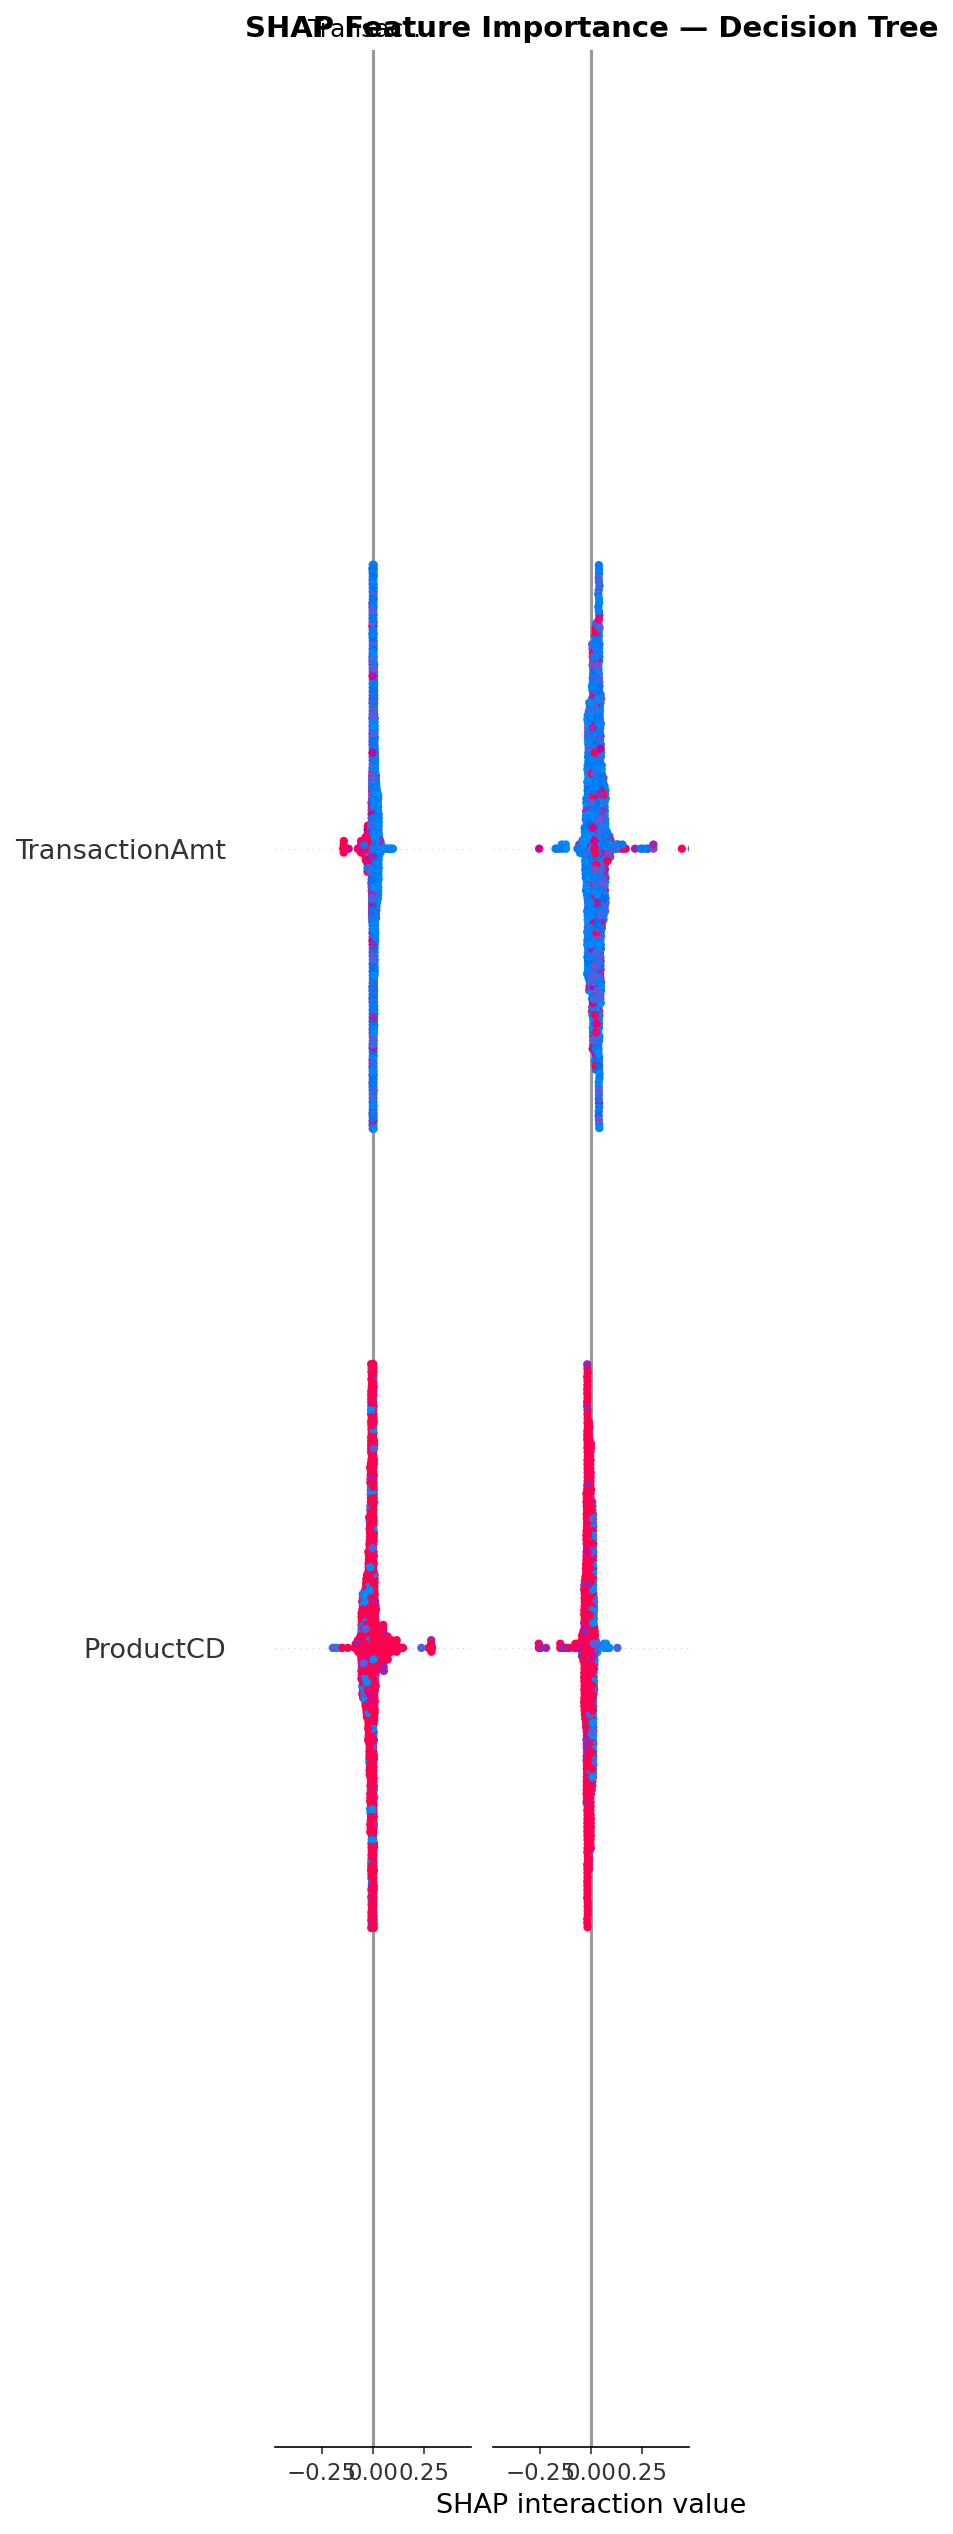


════════════════════════════════════════════════════════════
  SHAP Summary — XGBoost
════════════════════════════════════════════════════════════


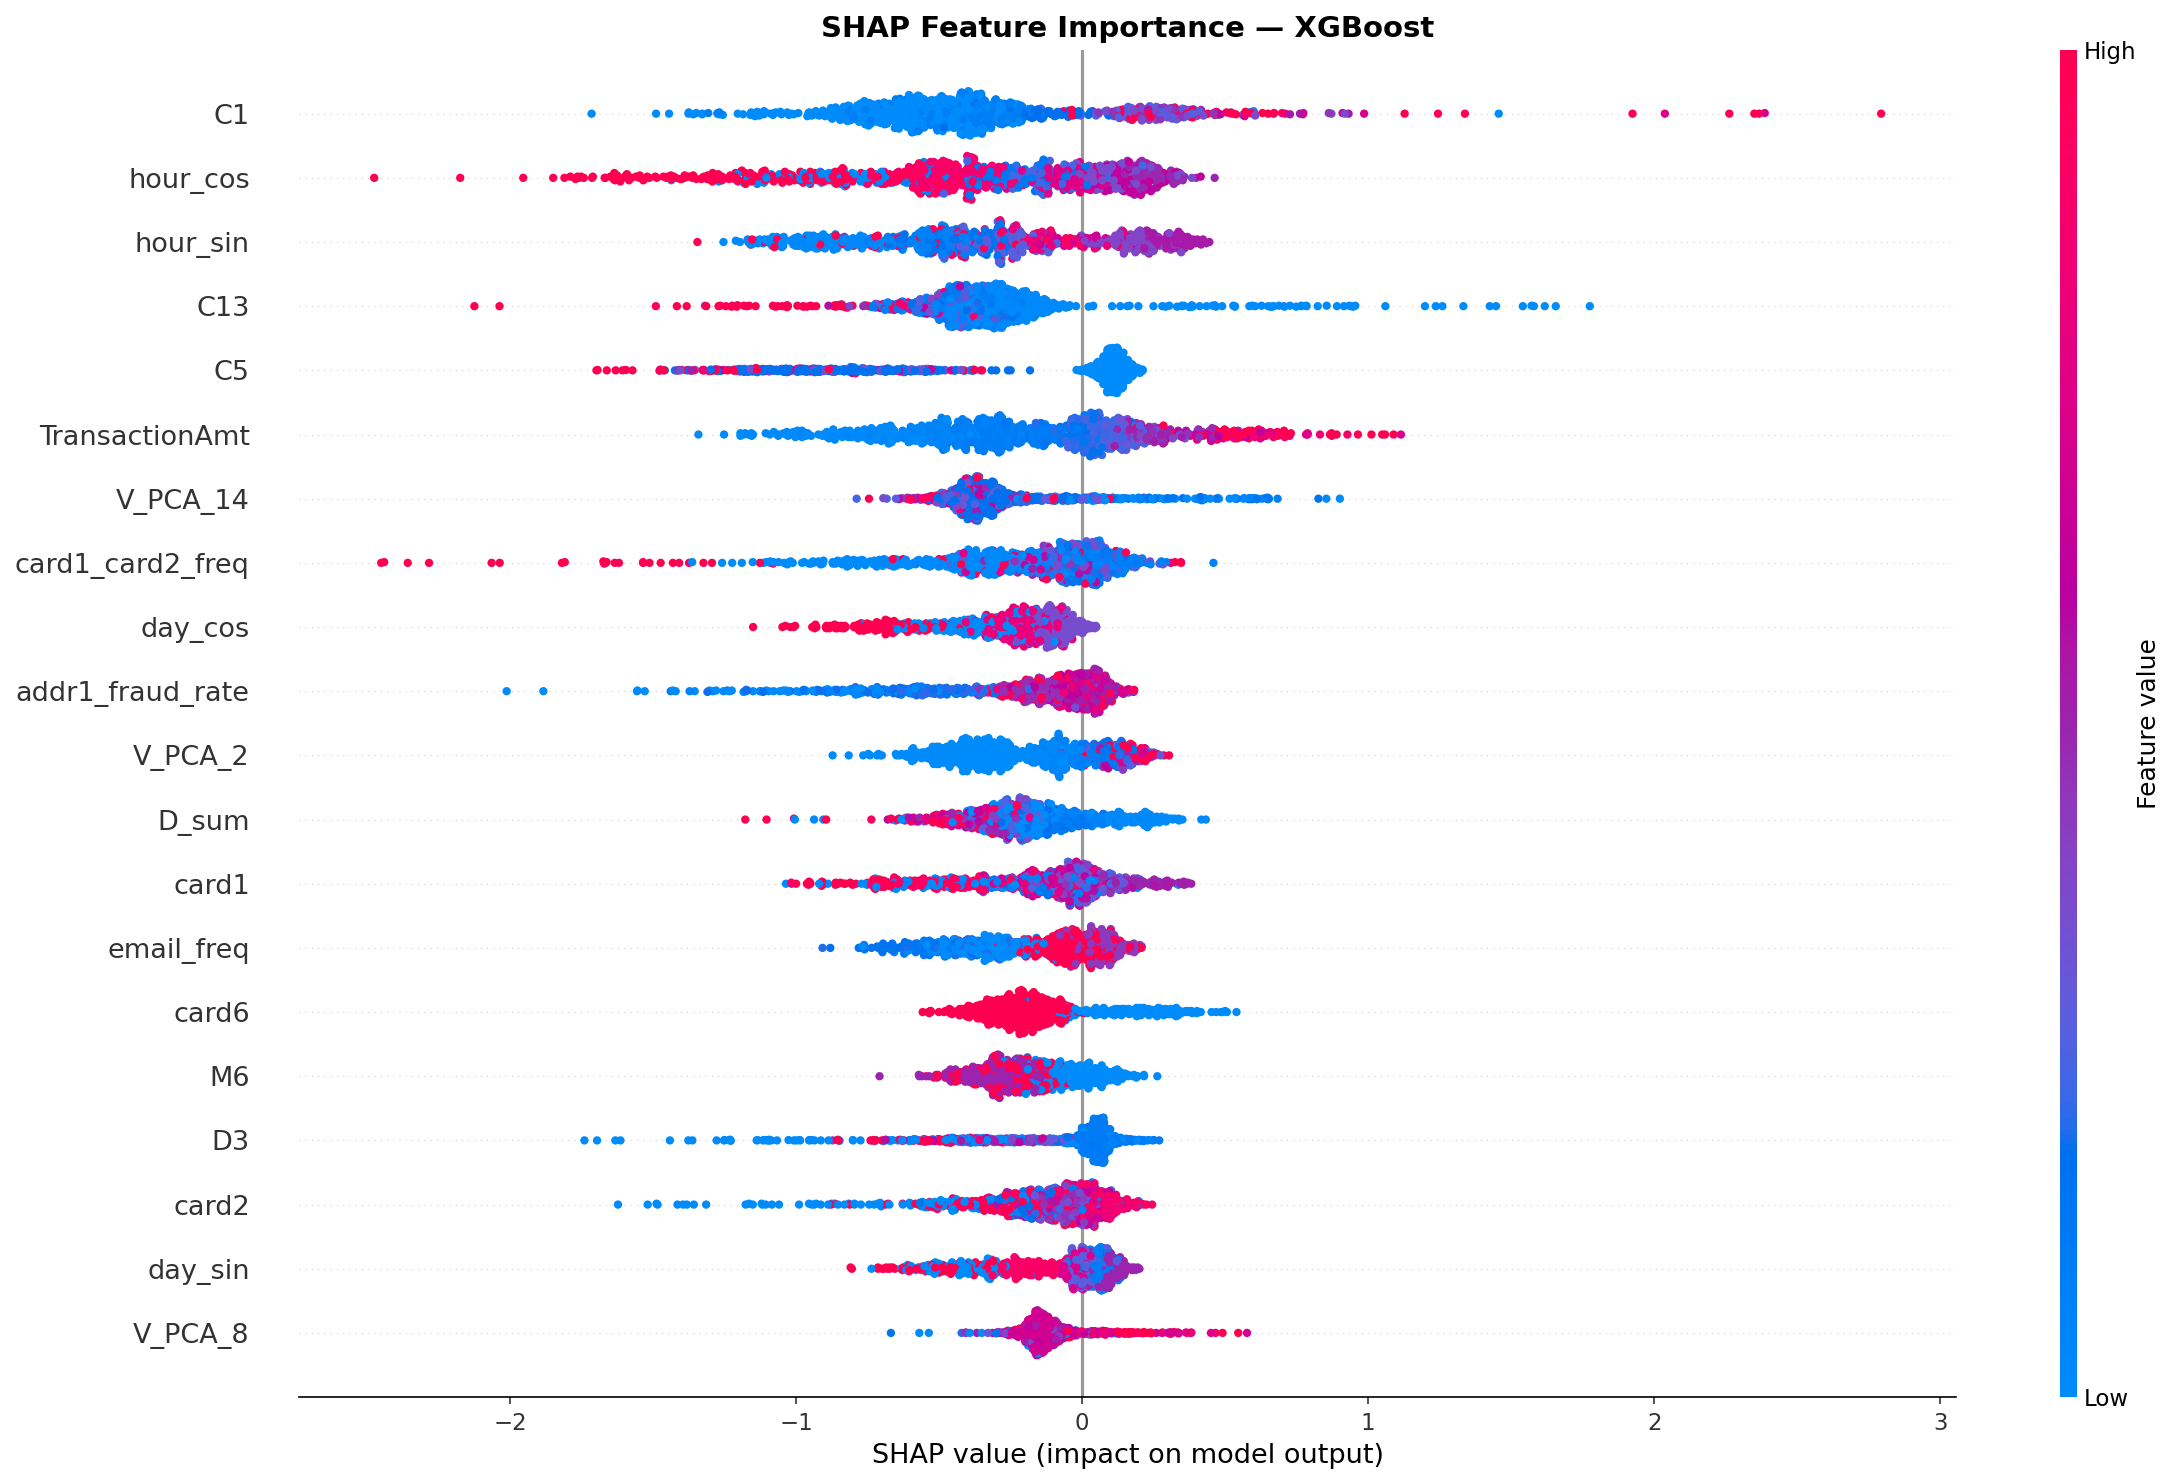


════════════════════════════════════════════════════════════
  Feature Importance Comparison
════════════════════════════════════════════════════════════


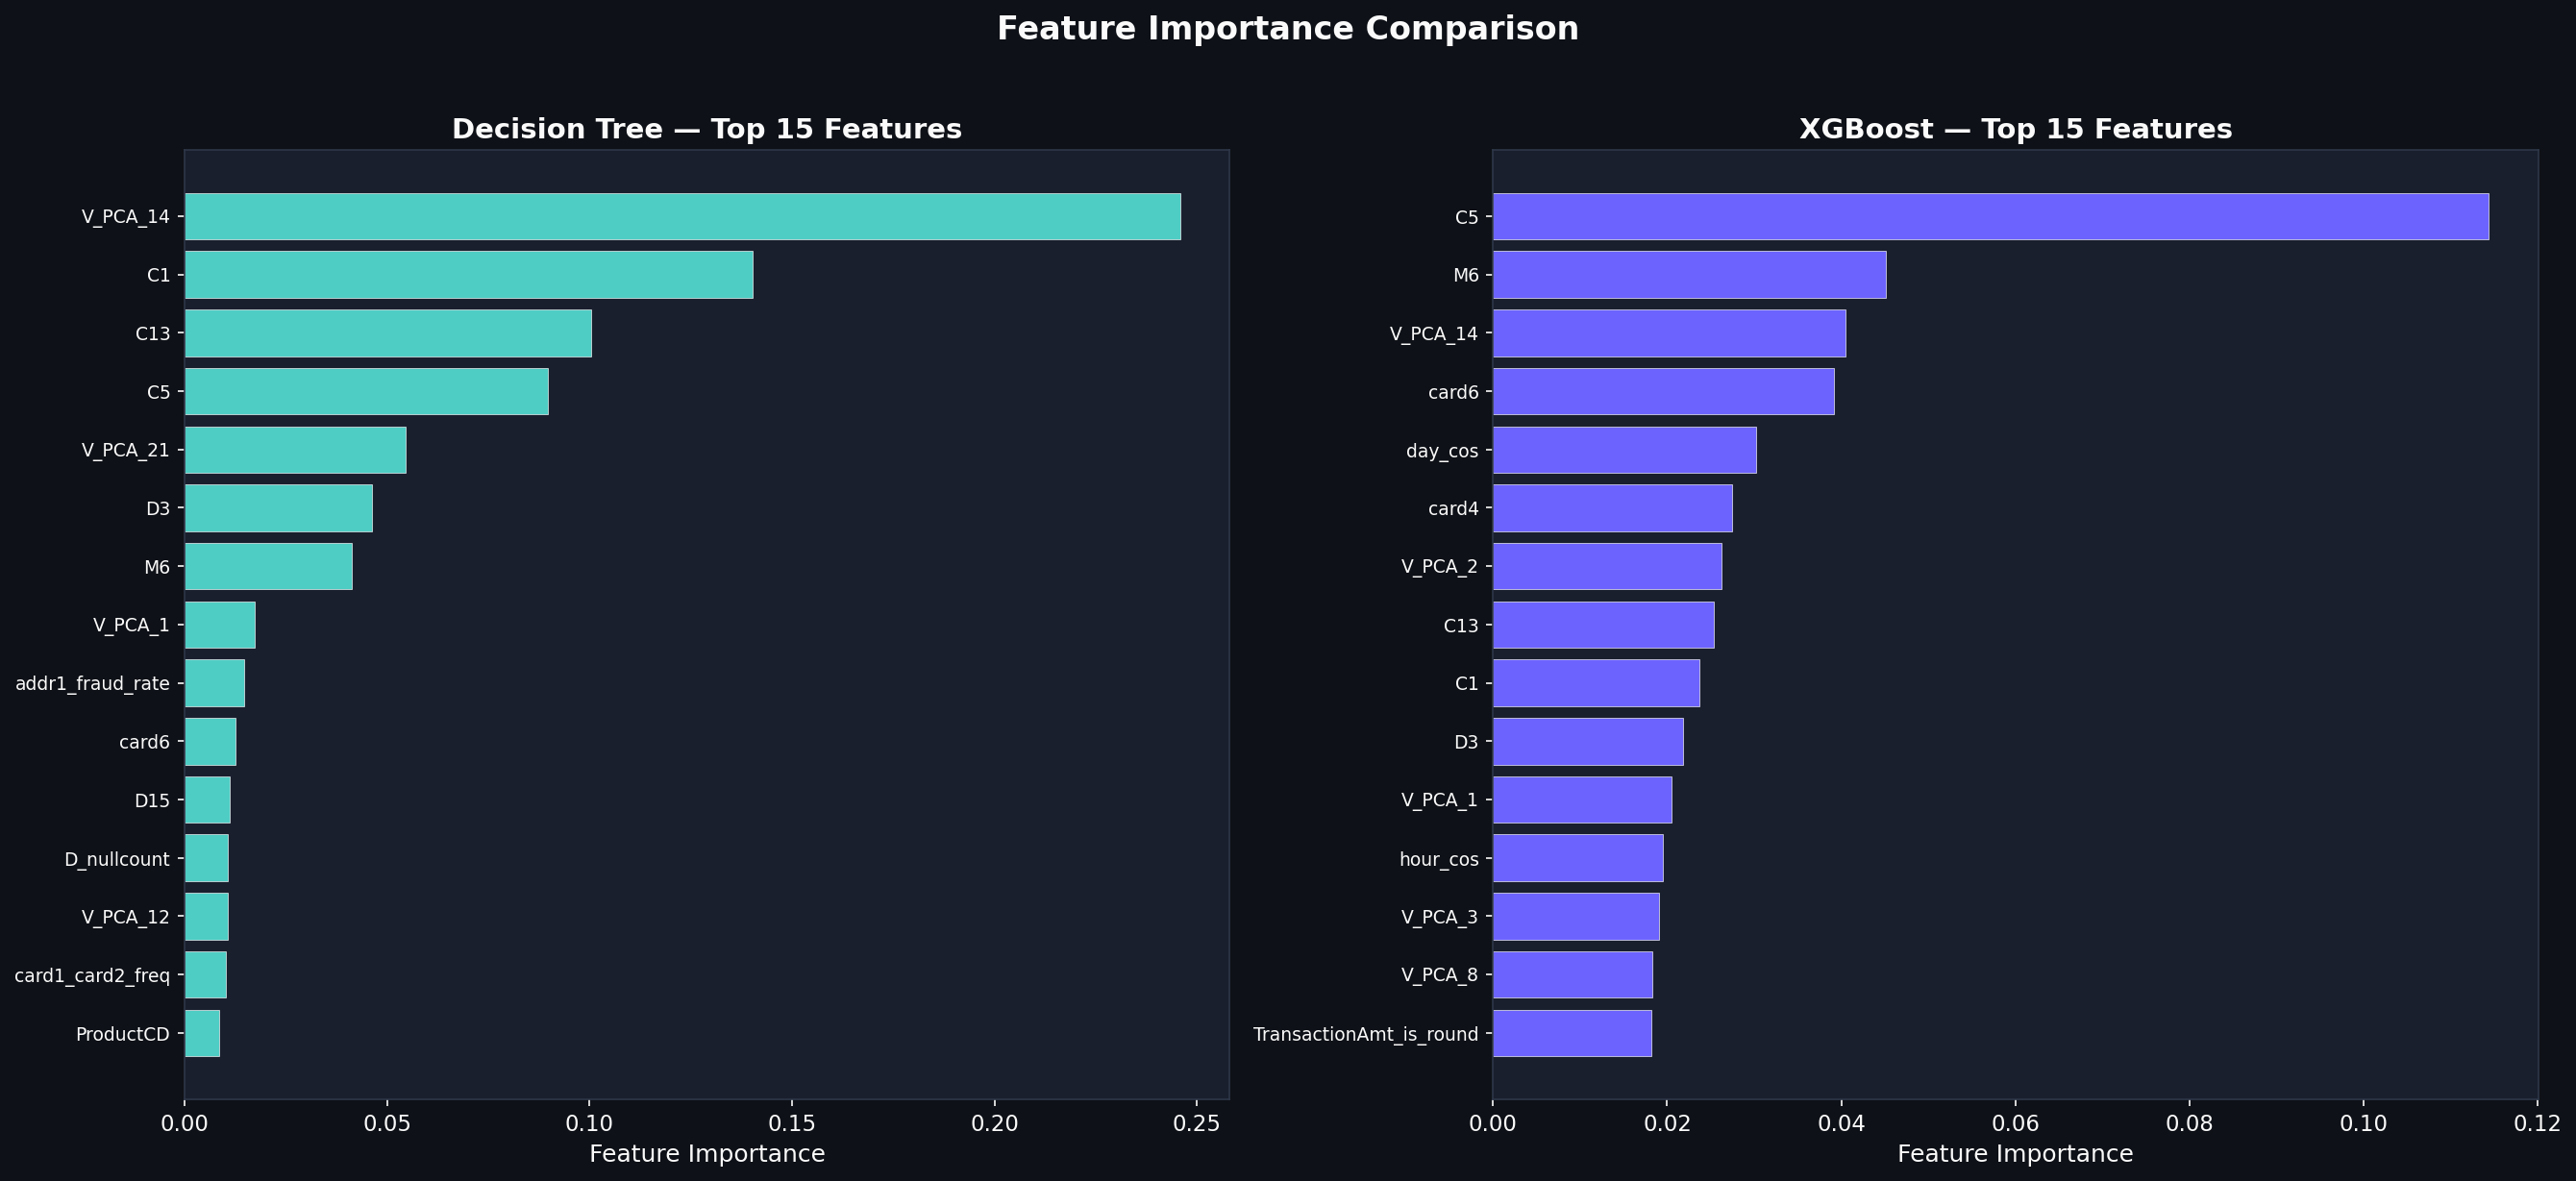


════════════════════════════════════════════════════════════
  Decision Tree Structure
════════════════════════════════════════════════════════════


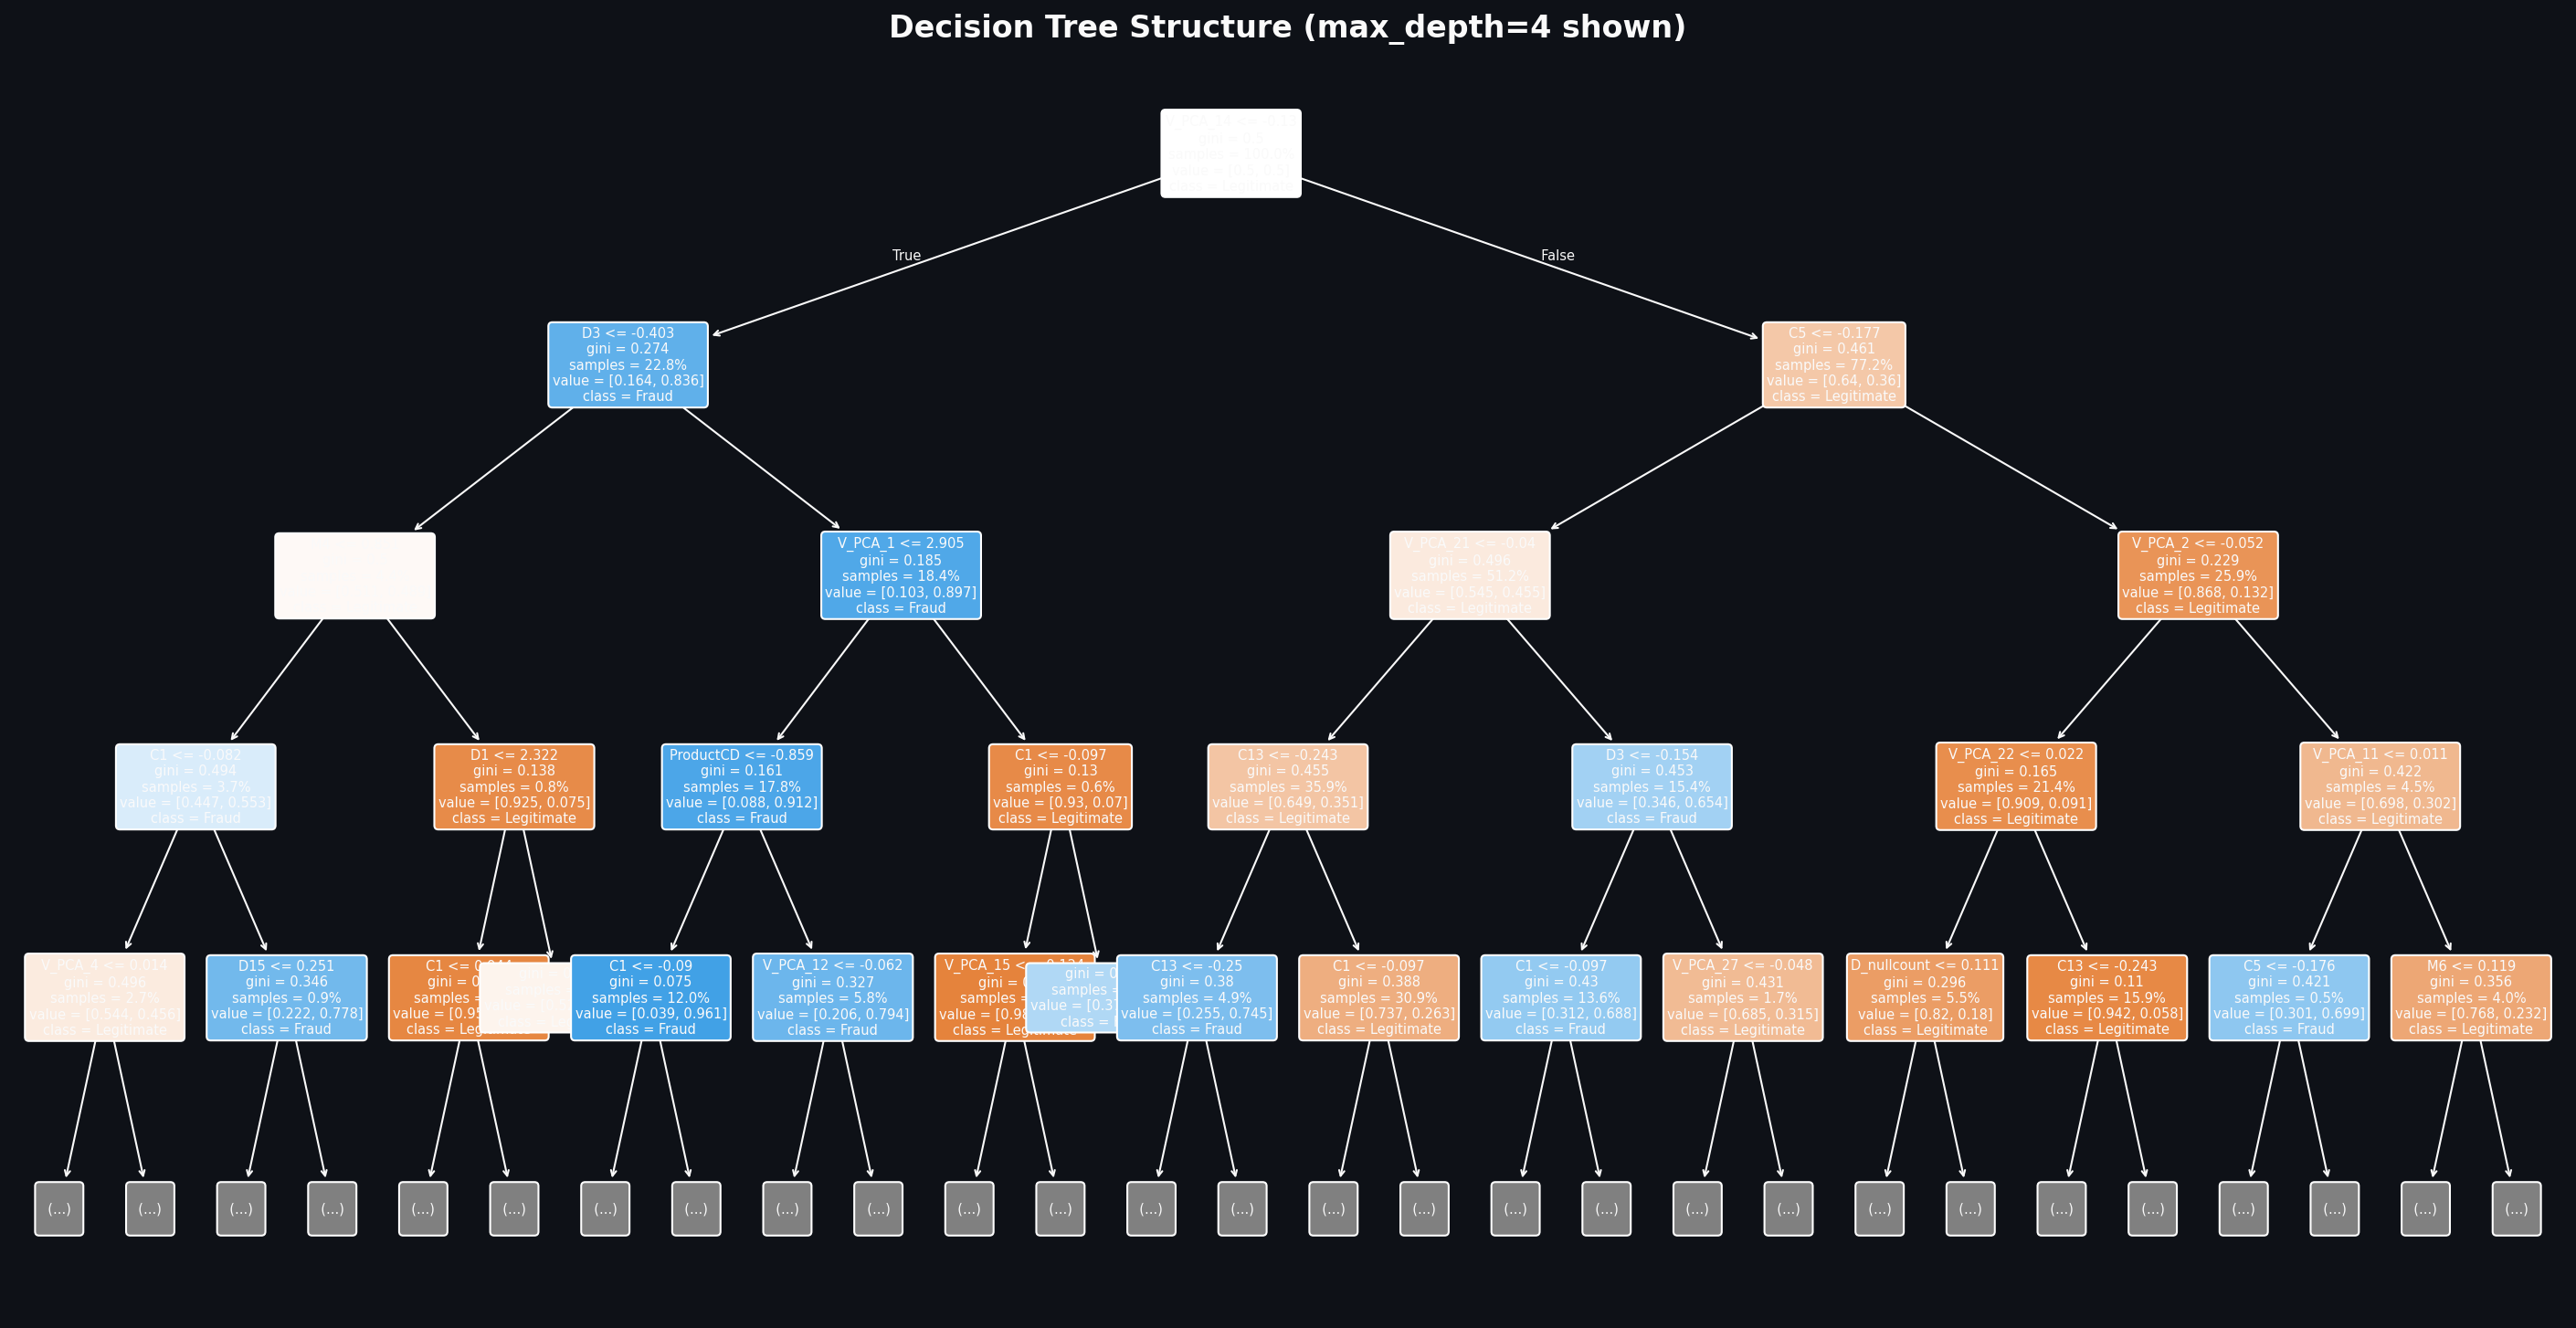

In [10]:
# ════════════════════════════════════════════════════════════════
# STAGE 8: EXPLAINABILITY
# ════════════════════════════════════════════════════════════════

from IPython.display import Image, display
from src.explainability import run_explainability_pipeline

run_explainability_pipeline(models, X_test, feature_names)

# Display explainability plots
explain_plots = [
    ('SHAP Summary — Decision Tree', '01_shap_summary_decision_tree.png'),
    ('SHAP Summary — XGBoost', '01_shap_summary_xgboost.png'),
    ('Feature Importance Comparison', '03_feature_importance_comparison.png'),
    ('Decision Tree Structure', '04_decision_tree_structure.png'),
]

for title, filename in explain_plots:
    path = os.path.join(EXPLAIN_DIR, filename)
    if os.path.exists(path):
        print(f'\n{"═"*60}')
        print(f'  {title}')
        print(f'{"═"*60}')
        display(Image(filename=path, width=900))

---
## 📚 Conclusions & Future Work

### Key Findings
1. **XGBoost** consistently outperforms Decision Trees and Neural Networks on this tabular fraud dataset
2. **SMOTE + cost-sensitive learning** together provide the best recall (minimizing missed frauds)
3. **Threshold optimization** using PR curves is critical — default 0.5 is suboptimal for imbalanced data
4. **Cost-benefit analysis** reveals the economically optimal operating point differs from the F1-optimal point
5. **SHAP analysis** shows transaction amount, V-features (anonymized), and card details are the most important predictors

### Limitations
- V-features are anonymized, limiting domain interpretation
- SMOTE may create unrealistic synthetic samples in high dimensions
- Neural network benefits from more data; may be under-utilized here

### Future Work
- Implement **LightGBM** and **CatBoost** for additional comparison
- Explore **under-sampling** techniques (Tomek links, NearMiss)
- Add **real-time stream processing** for production deployment
- Implement **A/B testing** framework for threshold selection

---
